# Part 1: Problem Definition and Data Collection

## Problem Definition and Data Collection

The objective of this project is to develop a machine learning model capable of predicting residential property sale prices in Sydney using historical housing data. Housing price prediction is a valuable real-world problem because accurate price estimates can assist home buyers, sellers, investors, and real estate professionals in making informed decisions. For this study, three Sydney suburbs were selected: Parramatta, Ryde, and Mosman. These suburbs were intentionally chosen because they represent distinctly different housing markets. Parramatta is a major commercial and transport hub in Western Sydney with significant redevelopment activity, Ryde represents a well-established middle-ring residential market with strong accessibility to employment centres, while Mosman is a premium harbourside suburb characterised by high property values and limited housing supply. These differences provide a diverse dataset and allow the analysis of how location influences property prices. 
The dataset was manually collected from publicly available sold-property listings on Sold House Prices & Auction Results in Parramatta, NSW 2150, Sold House Prices & Auction Results in Ryde, NSW 2112, and Sold Real Estate & Property in Mosman, NSW 2088. For each property, the sale price was collected as the target variable together with relevant features including bedrooms, bathrooms, car spaces, land size, building size, storeys, renovation status, development potential, views, and distance to the CBD. These characteristics were selected because they are commonly associated with property value and buyer demand. 
Although the dataset was collected from reputable real estate websites, several data quality issues were identified. Some listings did not disclose attributes such as building size, renovation history, sale method, or development potential, resulting in missing values. In addition, the dataset may contain selection bias because only sold properties were included, and premium suburbs such as Mosman are overrepresented in higher price ranges. Furthermore, market conditions vary across time, and some property characteristics were not consistently reported across listings. These limitations may affect model accuracy and should be considered during data preprocessing and interpretation of results. 


# Part 2: Data Understanding and Feature Engineering

In [25]:
# Load modules

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Load the dataset

file_path = r"C:\ML_MiniProj\Property_Dataset.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (150, 24)


## 2.1 Dataset Structure and Initial Understanding

The dataset contains 150 property records and 24 variables. The properties are distributed across three Sydney suburbs, with 50 properties from each suburb. The dataset contains property characteristics such as bedrooms, bathrooms, car spaces, land size, building size and storeys, as well as location, sale method and sale year information. `Sale_Price` is the target variable for the housing price prediction task.


In [14]:
# Display the first five records

df.head()

,Property_ID,Suburb,Address,Sale_Price,Bedrooms,Bathrooms,Car_Spaces,Land_Size_m2,Building_Size_m2,Storeys,...,Ensuite,Renovated,Land_Value,Development_Potential,View,Distance_to_Train_km,Distance_to_CBD_km,Sale_Method,Days_On_Market,Sale_Year
0,PAR001,Parramatta,58 Crimea Street,1620000.0,3.0,2.0,2.0,613.4,290,1,...,No,Partial,Estimated,Yes,Park/City Outlook,1.5,24,Private Treaty,30,2026
1,PAR002,Parramatta,114 Thomas Street,1360000.0,3.0,2.0,1.0,381,178,2,...,Yes,Updated,Estimated,Yes,NaN,1.2,24,Private Treaty,30,2025
2,PAR003,Parramatta,38 Inkerman Street,2010500.0,3.0,2.0,4.0,698.6,246,1,...,Yes,Fully Renovated,Estimated,Moderate,NaN,1.0,24,Auction,30,2025
3,PAR004,Parramatta,71 Pitt Street,1771000.0,6.0,2.0,5.0,455.3,205,2,...,Yes,Unknown,Estimated,Moderate,NaN,1.3,24,Private Treaty,30,2025
4,PAR005,Parramatta,9 Carrington Street,1785000.0,5.0,3.0,2.0,455,205,2,...,Yes,Unknown,Estimated,Moderate,NaN,1.2,24,Private Treaty,30,2025


In [15]:
# Display dataset dimensions and column names

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 150
Number of columns: 24

Column names:
['Property_ID', 'Suburb', 'Address', 'Sale_Price', 'Bedrooms', 'Bathrooms', 'Car_Spaces', 'Land_Size_m2', 'Building_Size_m2', 'Storeys', 'Garage', 'Pool', 'Air_Conditioning', 'Study', 'Ensuite', 'Renovated', 'Land_Value', 'Development_Potential', 'View', 'Distance_to_Train_km', 'Distance_to_CBD_km', 'Sale_Method', 'Days_On_Market', 'Sale_Year']


In [16]:
# Display data types and non-null information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Property_ID            150 non-null    object 
 1   Suburb                 150 non-null    object 
 2   Address                150 non-null    object 
 3   Sale_Price             149 non-null    float64
 4   Bedrooms               149 non-null    float64
 5   Bathrooms              149 non-null    float64
 6   Car_Spaces             146 non-null    float64
 7   Land_Size_m2           111 non-null    object 
 8   Building_Size_m2       150 non-null    int64  
 9   Storeys                150 non-null    int64  
 10  Garage                 150 non-null    object 
 11  Pool                   150 non-null    object 
 12  Air_Conditioning       150 non-null    object 
 13  Study                  150 non-null    object 
 14  Ensuite                150 non-null    object 
 15  Renova

In [17]:
# Generate descriptive statistics for all variables

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Property_ID,150,150,PAR001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Suburb,150,3,Parramatta,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Address,150,150,58 Crimea Street,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sale_Price,149.0,NaN,NaN,NaN,3731452.268456,3089104.702478,0.0,1750000.0,2400000.0,5300000.0,14600000.0
Bedrooms,149.0,NaN,NaN,NaN,4.167785,1.210331,2.0,3.0,4.0,5.0,12.0
Bathrooms,149.0,NaN,NaN,NaN,2.463087,1.016908,1.0,2.0,2.0,3.0,6.0
Car_Spaces,146.0,NaN,NaN,NaN,2.130137,0.888732,1.0,2.0,2.0,2.0,6.0
Land_Size_m2,111,97,455.3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Building_Size_m2,150.0,NaN,NaN,NaN,266.453333,82.234204,105.0,207.0,250.0,324.0,612.0
Storeys,150.0,NaN,NaN,NaN,1.386667,0.488618,1.0,1.0,1.0,2.0,2.0


## 2.2 Data Quality Assessment

The initial data-quality assessment identified several missing values and data-type issues. `Land_Size_m2` is stored as an object rather than a numerical variable and requires conversion before modelling. Missing values are present in `Sale_Price`, `Bedrooms`, `Bathrooms`, `Car_Spaces`, `Land_Size_m2`, and `View`. `View` has 149 missing values out of 150 observations (99.33%) and therefore provides very limited usable information.

The dataset contains no duplicate rows, and all 150 `Property_ID` values are unique. This indicates that each property record can be uniquely identified.

The dataset also contains variables with little or no variation. For example, `Pool`, `Air_Conditioning`, `Study`, `Land_Value`, and `Days_On_Market` have the same value for all observations. `Garage` also has very little variation. These variables provide little or no predictive information and will be considered for exclusion during model preparation.

The missing values and low-variation variables will be addressed during data preparation before model development, while the original dataset will be retained for reference.


In [18]:
# Check missing values

missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary[missing_summary["Missing_Count"] > 0].sort_values(
    "Missing_Count", ascending=False
)

,Missing_Count,Missing_Percentage
View,149,99.33
Land_Size_m2,39,26.00
Car_Spaces,4,2.67
Sale_Price,1,0.67
Bedrooms,1,0.67
Bathrooms,1,0.67


In [21]:
# Check for duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

# Check uniqueness of Property_ID

print()
print("Total records:", len(df))
print("Unique Property_IDs:", df["Property_ID"].nunique())


Number of duplicate rows: 0

Total records: 150
Unique Property_IDs: 150


## 2.3 Descriptive Statistics

Descriptive statistics are used to compare the properties across the three selected Sydney suburbs. The analysis examines the number of properties collected from each suburb and compares key numerical characteristics such as sale price, bedrooms, bathrooms, land size, building size, and distance to the CBD.


In [22]:
# Count properties by suburb

suburb_counts = df["Suburb"].value_counts()

print("Number of properties by suburb:")
print(suburb_counts)

Number of properties by suburb:
Suburb
Parramatta    50
Ryde          50
Mosman        50
Name: count, dtype: int64


In [23]:
# Compare key numerical variables by suburb

suburb_summary = df.groupby("Suburb")[
    [
        "Sale_Price",
        "Bedrooms",
        "Bathrooms",
        "Car_Spaces",
        "Building_Size_m2",
        "Distance_to_Train_km",
        "Distance_to_CBD_km"
    ]
].mean().round(2)

suburb_summary

,Sale_Price,Bedrooms,Bathrooms,Car_Spaces,Building_Size_m2,Distance_to_Train_km,Distance_to_CBD_km
Suburb,,,,,,,
Mosman,7453204.08,4.60,2.96,2.19,327.56,2.80,8.0
Parramatta,1714290.00,3.86,1.94,1.98,221.52,1.24,24.0
Ryde,2101297.76,4.04,2.48,2.22,250.28,1.57,13.0


The descriptive statistics show clear differences between the three suburbs. Mosman has the highest average sale price at approximately $7.45 million, followed by Ryde at approximately $2.10 million and Parramatta at approximately $1.71 million. Mosman properties also have, on average, more bedrooms, bathrooms and larger building sizes than the other two suburbs. Parramatta properties have the shortest average distance to a train station but the greatest average distance to the CBD in this dataset, while Mosman has the greatest average distance to a train station and the shortest average distance to the CBD. These differences indicate that suburb and property characteristics may be important predictors of sale price.


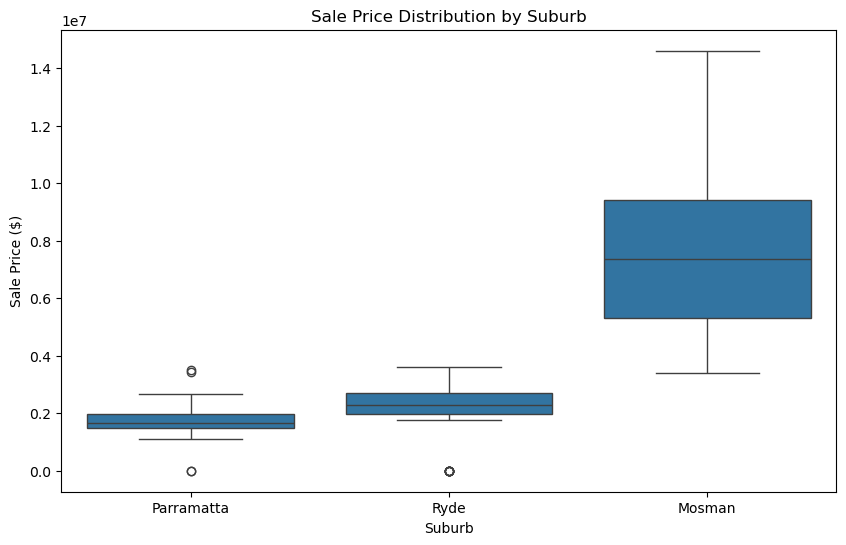

In [26]:
# Compare sale price distributions by suburb

plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x="Suburb", y="Sale_Price")

plt.title("Sale Price Distribution by Suburb")
plt.xlabel("Suburb")
plt.ylabel("Sale Price ($)")
plt.xticks(rotation=0)

plt.show()

In [27]:
# Sale price distribution by suburb

sale_price_by_suburb = df.groupby("Suburb")["Sale_Price"].describe().round(2)

sale_price_by_suburb

,count,mean,std,min,25%,50%,75%,max
Suburb,,,,,,,,
Mosman,49.0,7453204.08,2616900.02,3390000.0,5325000.0,7350000.0,9400000.0,14600000.0
Parramatta,50.0,1714290.00,596977.90,0.0,1485000.0,1674000.0,1989000.0,3502000.0
Ryde,50.0,2101297.76,1021079.69,0.0,1967500.0,2270000.0,2700000.0,3620000.0


In [28]:
# Inspect records with missing or zero sale prices

price_issues = df[
    df["Sale_Price"].isna() | (df["Sale_Price"] == 0)
]

price_issues[
    ["Property_ID", "Suburb", "Address", "Sale_Price"]
]

,Property_ID,Suburb,Address,Sale_Price
43,PAR044,Parramatta,48 Crimea Street,0.0
55,RYD006,Ryde,27 Shepherd Street,0.0
56,RYD007,Ryde,44 Hancott Street,0.0
58,RYD009,Ryde,60 Lardelli Drive,0.0
59,RYD010,Ryde,15 Quarry Road,0.0
60,RYD011,Ryde,12 Collingridge Drive,0.0
62,RYD013,Ryde,8 Cressy Road,0.0
63,RYD014,Ryde,2/14 Frederick Street,0.0
64,RYD015,Ryde,4 Ronald Avenue,0.0
149,MOS050,Mosman,45 Ourimbah Road,NaN


In [29]:
# Inspect all details of records with zero or missing sale prices

price_issues = df[
    df["Sale_Price"].isna() | (df["Sale_Price"] == 0)
]

price_issues.T

,43,55,56,58,59,60,62,63,64,149
Property_ID,PAR044,RYD006,RYD007,RYD009,RYD010,RYD011,RYD013,RYD014,RYD015,MOS050
Suburb,Parramatta,Ryde,Ryde,Ryde,Ryde,Ryde,Ryde,Ryde,Ryde,Mosman
Address,48 Crimea Street,27 Shepherd Street,44 Hancott Street,60 Lardelli Drive,15 Quarry Road,12 Collingridge Drive,8 Cressy Road,2/14 Frederick Street,4 Ronald Avenue,45 Ourimbah Road
Sale_Price,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
Bedrooms,4.0,5.0,4.0,3.0,2.0,5.0,4.0,4.0,4.0,4.0
Bathrooms,2.0,3.0,2.0,3.0,1.0,4.0,1.0,2.0,3.0,2.0
Car_Spaces,2.0,2.0,2.0,2.0,2.0,4.0,2.0,1.0,3.0,2.0
Land_Size_m2,291,721,686,NaN,657,473,NaN,NaN,NaN,NaN
Building_Size_m2,131,324,309,250,296,213,250,250,250,334
Storeys,1,2,1,1,1,2,1,1,1,1


In [30]:
# Identify invalid sale prices

invalid_price_count = ((df["Sale_Price"].isna()) | (df["Sale_Price"] <= 0)).sum()

print("Invalid or missing sale prices:", invalid_price_count)
print("Valid positive sale prices:", len(df) - invalid_price_count)

Invalid or missing sale prices: 10
Valid positive sale prices: 140


In [31]:
# Create modelling dataset with valid sale prices only

df_model = df[df["Sale_Price"] > 0].copy()

print("Original dataset shape:", df.shape)
print("Modelling dataset shape:", df_model.shape)

Original dataset shape: (150, 24)
Modelling dataset shape: (140, 24)


## 2.4 Sale Price Distribution

The distribution of the target variable, `Sale_Price`, is examined to understand the overall range, central tendency and variability of property prices. The analysis uses only valid positive sale prices because missing and zero sale prices cannot represent meaningful residential transaction values. A histogram is used to assess the shape of the distribution and identify potential skewness or extreme observations.


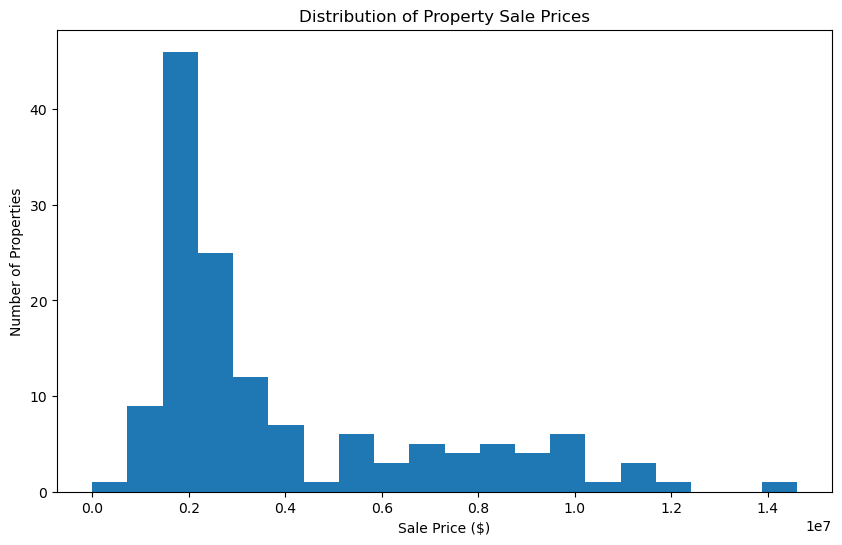

In [32]:
# Examine the distribution of sale prices

plt.figure(figsize=(10, 6))

plt.hist(df_model["Sale_Price"], bins=20)

plt.title("Distribution of Property Sale Prices")
plt.xlabel("Sale Price ($)")
plt.ylabel("Number of Properties")

plt.show()

In [33]:
# Summary statistics for valid sale prices

sale_price_stats = df_model["Sale_Price"].describe().round(2)

sale_price_stats

count         140.00
mean      3971331.34
std       3033304.99
min          1000.00
25%       1800000.00
50%       2595000.00
75%       5528000.00
max      14600000.00
Name: Sale_Price, dtype: float64

In [34]:
# Inspect unusually low sale prices

df_model.nsmallest(
    10, "Sale_Price"
)[
    ["Property_ID", "Suburb", "Address", "Sale_Price", "Bedrooms",
     "Bathrooms", "Building_Size_m2", "Sale_Year"]
]

,Property_ID,Suburb,Address,Sale_Price,Bedrooms,Bathrooms,Building_Size_m2,Sale_Year
20,PAR021,Parramatta,19 Wandsworth Street,1000.0,2.0,1.0,152,2024
31,PAR032,Parramatta,102A Crimea Street,1100000.0,3.0,1.0,138,2024
33,PAR034,Parramatta,101 Railway Street,1150000.0,3.0,2.0,173,2024
48,PAR049,Parramatta,76 O'Connell Street,1150000.0,3.0,1.0,114,2025
18,PAR019,Parramatta,100 Crimea Street,1200000.0,3.0,2.0,137,2025
16,PAR017,Parramatta,109 Victoria Road,1248000.0,5.0,2.0,178,2025
46,PAR047,Parramatta,57 Pitt Street,1310000.0,4.0,2.0,106,2026
1,PAR002,Parramatta,114 Thomas Street,1360000.0,3.0,2.0,178,2025
6,PAR007,Parramatta,4 Alma Street,1430000.0,3.0,1.0,262,2025
34,PAR035,Parramatta,121 Victoria Road,1460000.0,5.0,3.0,157,2023


The sale-price distribution is strongly right-skewed, with a mean sale price of approximately $3.97 million compared with a median of approximately $2.60 million. The valid sale prices range from $1,000 to $14.6 million. The $1,000 observation was identified as an anomalous value because it is substantially below the other residential sale prices despite having otherwise plausible property characteristics. It will therefore be treated as an invalid target value and excluded from the modelling dataset. The distribution also indicates substantial variation in property prices across the three suburbs.


In [35]:
# Remove the anomalous $1,000 sale price

df_model = df_model[df_model["Sale_Price"] > 1000].copy()

print("Modelling dataset shape after removing invalid sale price:", df_model.shape)
print("Minimum sale price:", df_model["Sale_Price"].min())

Modelling dataset shape after removing invalid sale price: (139, 24)
Minimum sale price: 1100000.0


## 2.5 Outlier Investigation

Outlier analysis is performed to identify observations with unusually high or low sale prices and property characteristics. An extreme value is not automatically considered an error, as expensive properties may legitimately have substantially higher sale prices. Therefore, statistical outliers are investigated alongside the underlying property characteristics before deciding whether they should be retained or removed.


In [36]:
# Identify statistical outliers in sale price using the IQR method

Q1 = df_model["Sale_Price"].quantile(0.25)
Q3 = df_model["Sale_Price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

sale_price_outliers = df_model[
    (df_model["Sale_Price"] < lower_bound) |
    (df_model["Sale_Price"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

print("\nNumber of statistical sale-price outliers:",
      len(sale_price_outliers))

sale_price_outliers[
    ["Property_ID", "Suburb", "Address", "Sale_Price",
     "Bedrooms", "Bathrooms", "Building_Size_m2", "Sale_Year"]
].sort_values("Sale_Price")

Q1: 1825000.0
Q3: 5556000.0
IQR: 3731000.0
Lower bound: -3771500.0
Upper bound: 11152500.0

Number of statistical sale-price outliers: 4


,Property_ID,Suburb,Address,Sale_Price,Bedrooms,Bathrooms,Building_Size_m2,Sale_Year
109,MOS010,Mosman,5 The Grove,11360000.0,4.0,3.0,297,2025
105,MOS006,Mosman,6 Lavoni Street,11550000.0,7.0,4.0,322,2025
113,MOS014,Mosman,2 Edwards Bay Road,12400000.0,4.0,5.0,334,2025
114,MOS015,Mosman,99 Muston Street,14600000.0,5.0,4.0,307,2025


The IQR method identified four statistical outliers in sale price, with an upper bound of approximately $11.15 million. All four outliers are properties in Mosman, with sale prices ranging from $11.36 million to $14.60 million. Their property characteristics, including 4–7 bedrooms, 3–5 bathrooms and building sizes of approximately 297–334 m², are consistent with high-value residential properties.

Therefore, these observations are considered potentially legitimate high-value properties rather than data-entry errors. They will be retained in the modelling dataset because removing genuine high-value properties could reduce the model's ability to predict prices across different segments of the Sydney housing market.


In [37]:
# Check numerical variables for statistical outliers

numerical_columns = [
    "Bedrooms",
    "Bathrooms",
    "Car_Spaces",
    "Building_Size_m2",
    "Distance_to_Train_km",
    "Distance_to_CBD_km"
]

outlier_summary = []

for column in numerical_columns:
    Q1 = df_model[column].quantile(0.25)
    Q3 = df_model[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df_model[column] < lower) |
             (df_model[column] > upper)).sum()

    outlier_summary.append([
        column, Q1, Q3, lower, upper, count
    ])

outlier_summary = pd.DataFrame(
    outlier_summary,
    columns=[
        "Variable", "Q1", "Q3",
        "Lower_Bound", "Upper_Bound",
        "Outlier_Count"
    ]
)

outlier_summary

,Variable,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Count
0,Bedrooms,3.0,5.0,0.00,8.00,1
1,Bathrooms,2.0,3.0,0.50,4.50,5
2,Car_Spaces,2.0,2.0,2.00,2.00,53
3,Building_Size_m2,207.0,333.0,18.00,522.00,1
4,Distance_to_Train_km,1.3,2.8,-0.95,5.05,0
5,Distance_to_CBD_km,8.0,24.0,-16.00,48.00,0


The IQR analysis of the numerical predictors identified a small number of potential outliers in bedrooms, bathrooms and building size. The bedroom and building-size outliers are not automatically treated as errors because they may represent larger residential properties. Five bathroom observations fall outside the IQR bounds, but the values should be assessed in the context of the property characteristics rather than removed solely because of the statistical rule.

The IQR method produces 53 apparent outliers for `Car_Spaces` because both the first and third quartiles are 2, resulting in an IQR of zero. This demonstrates a limitation of applying the IQR rule to a variable with very little variation. These observations will therefore not be removed based on this test.

Overall, the outlier analysis does not provide sufficient evidence to remove the identified observations. The four high-value Mosman properties and other potential predictor outliers will be retained because they may represent genuine characteristics of the housing market.


## 2.6 Relationship Between Features and Sale Price

The relationships between numerical property characteristics and sale price are examined to identify potentially important predictors for the regression model. Correlation analysis is used as an initial measure of the strength and direction of linear relationships. Because correlation does not establish causation and may not capture nonlinear relationships, the results are interpreted alongside the characteristics of the housing data.


In [38]:
# Calculate correlations between numerical variables and sale price

correlation_with_price = (
    df_model[
        [
            "Sale_Price",
            "Bedrooms",
            "Bathrooms",
            "Car_Spaces",
            "Building_Size_m2",
            "Distance_to_Train_km",
            "Distance_to_CBD_km"
        ]
    ]
    .corr()["Sale_Price"]
    .sort_values(ascending=False)
)

correlation_with_price

Sale_Price              1.000000
Distance_to_Train_km    0.820083
Building_Size_m2        0.587273
Bathrooms               0.483936
Bedrooms                0.370824
Car_Spaces              0.211841
Distance_to_CBD_km     -0.705649
Name: Sale_Price, dtype: float64

The correlation analysis shows different levels of association between the numerical property characteristics and sale price. `Distance_to_Train_km` has a strong positive correlation with sale price (0.820), while `Distance_to_CBD_km` has a strong negative correlation (-0.706). `Building_Size_m2` also shows a moderate positive correlation (0.587), followed by `Bathrooms` (0.484) and `Bedrooms` (0.371). `Car_Spaces` has a weaker positive correlation (0.212).

The positive relationship between distance to the train station and sale price may reflect the characteristics of the selected suburbs rather than indicating that greater distance directly increases property value. Similarly, the negative correlation between distance to the CBD and sale price is consistent with the higher-priced properties in the dataset being located closer to the CBD. These results should therefore be interpreted as associations rather than causal relationships.

The results suggest that property size, room numbers and location-related variables may provide useful information for predicting sale price. Further analysis will examine categorical variables and potential feature engineering before model development.


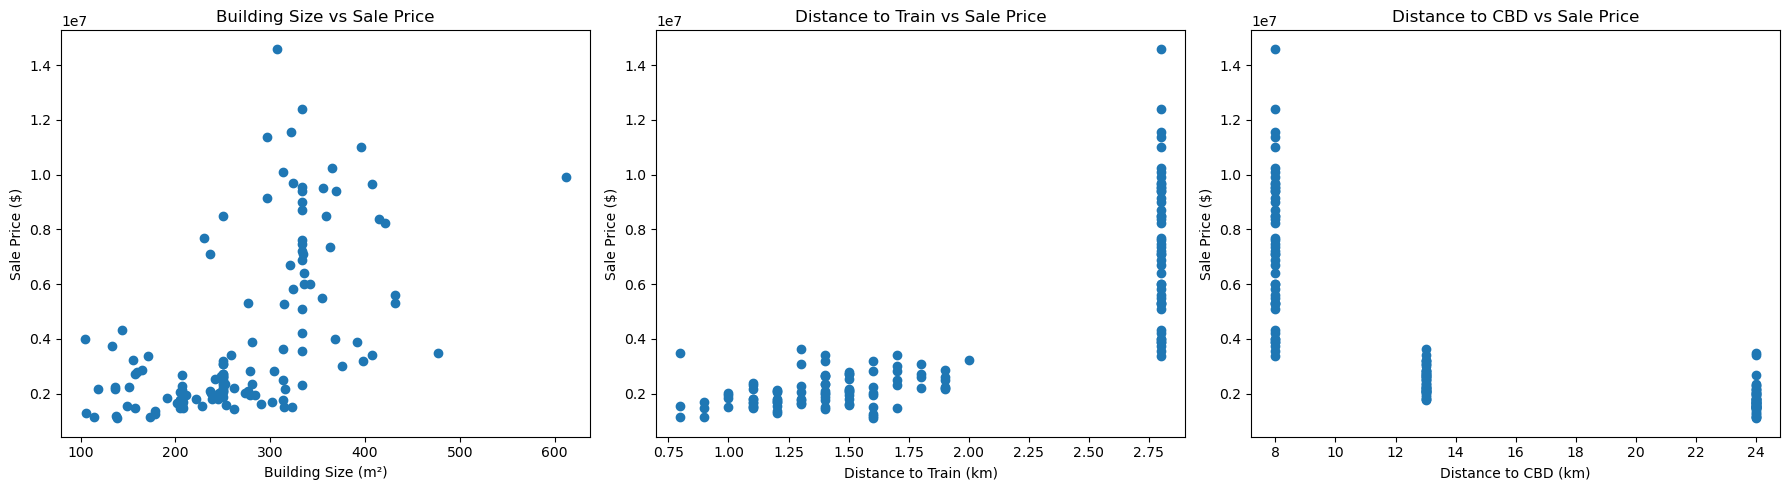

In [39]:
# Visualise the relationship between key numerical features and sale price

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(
    df_model["Building_Size_m2"],
    df_model["Sale_Price"]
)
axes[0].set_title("Building Size vs Sale Price")
axes[0].set_xlabel("Building Size (m²)")
axes[0].set_ylabel("Sale Price ($)")

axes[1].scatter(
    df_model["Distance_to_Train_km"],
    df_model["Sale_Price"]
)
axes[1].set_title("Distance to Train vs Sale Price")
axes[1].set_xlabel("Distance to Train (km)")
axes[1].set_ylabel("Sale Price ($)")

axes[2].scatter(
    df_model["Distance_to_CBD_km"],
    df_model["Sale_Price"]
)
axes[2].set_title("Distance to CBD vs Sale Price")
axes[2].set_xlabel("Distance to CBD (km)")
axes[2].set_ylabel("Sale Price ($)")

plt.tight_layout()
plt.show()

The scatter plots provide visual support for the correlation results. Building size shows an overall positive relationship with sale price, although the observations are dispersed. Distance to the train station shows clustered patterns, indicating that the relationship may be influenced by differences between the selected suburbs. Distance to the CBD shows a clearer negative relationship, with properties located farther from the CBD generally having lower sale prices in this dataset.

The scatter plots also demonstrate that relationships between individual numerical features and sale price are not necessarily simple or causal. In particular, location-related relationships may partly reflect differences between Parramatta, Ryde and Mosman. Therefore, suburb should be retained as an important categorical predictor when developing the regression models.


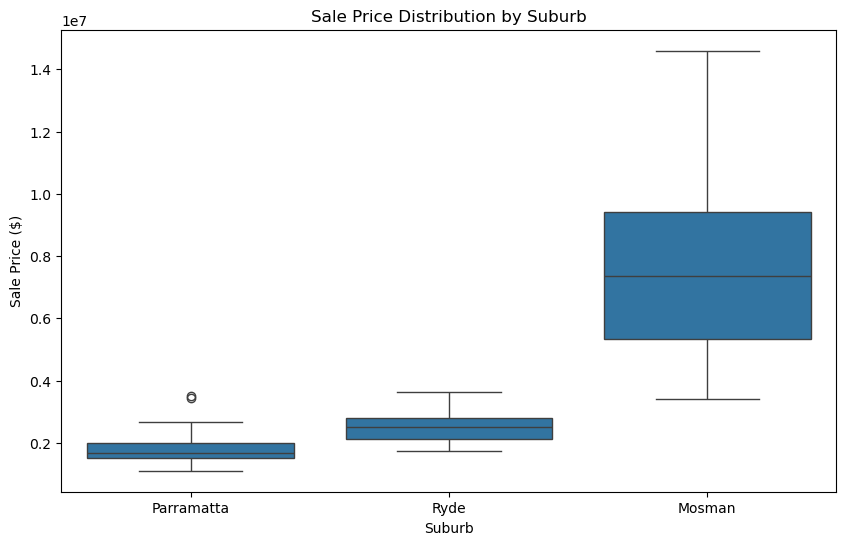

In [40]:
# Compare sale prices across suburbs

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_model,
    x="Suburb",
    y="Sale_Price"
)

plt.title("Sale Price Distribution by Suburb")
plt.xlabel("Suburb")
plt.ylabel("Sale Price ($)")

plt.show()

The boxplot shows a clear difference in sale-price distributions across the three suburbs. Mosman has a substantially higher distribution of sale prices than Parramatta and Ryde, while Parramatta and Ryde have lower and more overlapping distributions. This indicates that suburb is likely to be an important predictor of sale price in the modelling dataset.

The differences between suburbs also highlight the importance of including location information in the regression model. However, because the dataset contains only 50 originally collected properties per suburb and fewer valid observations after data-quality filtering, the observed differences should be interpreted within the limitations of the sample.


## 2.7 Feature Engineering

Feature engineering involves transforming existing variables and creating useful representations of the data to improve its suitability for machine learning. Before creating new features, the existing variables are inspected to identify data-type issues, variables requiring transformation, and variables that provide limited predictive information.


In [41]:
# Inspect the Land_Size_m2 variable

print("Data type:", df_model["Land_Size_m2"].dtype)
print("\nSample values:")
print(df_model["Land_Size_m2"].head(20).to_string())

print("\nNumber of missing values:",
      df_model["Land_Size_m2"].isna().sum())

Data type: object

Sample values:
0     613.4
1       381
2     698.6
3     455.3
4       455
5       449
6       582
7     467.9
8     455.3
9     455.3
10      560
11      332
12      670
13    543.7
14      NaN
15      NaN
16      396
17      303
18    303.5
19    423.7

Number of missing values: 34


In [42]:
# Convert Land_Size_m2 from object to numeric

df_model["Land_Size_m2"] = pd.to_numeric(
    df_model["Land_Size_m2"],
    errors="coerce"
)

print("Data type after conversion:", df_model["Land_Size_m2"].dtype)
print("Missing values after conversion:",
      df_model["Land_Size_m2"].isna().sum())

print("\nLand size summary:")
print(df_model["Land_Size_m2"].describe().round(2))

Data type after conversion: float64
Missing values after conversion: 35

Land size summary:
count     104.00
mean      597.54
std       205.05
min       233.00
25%       455.30
50%       594.50
75%       719.45
max      1359.00
Name: Land_Size_m2, dtype: float64


In [43]:
# Identify Land_Size_m2 values that are not numeric

land_size_original = df.loc[
    df["Property_ID"].isin(df_model["Property_ID"]),
    ["Property_ID", "Land_Size_m2"]
].copy()

land_size_original["Land_Size_Numeric"] = pd.to_numeric(
    land_size_original["Land_Size_m2"],
    errors="coerce"
)

non_numeric_land_size = land_size_original[
    land_size_original["Land_Size_m2"].notna() &
    land_size_original["Land_Size_Numeric"].isna()
]

non_numeric_land_size

,Property_ID,Land_Size_m2,Land_Size_Numeric
139,MOS040,,NaN


The `Land_Size_m2` variable was stored as an object data type even though the recorded values were predominantly numerical. The variable was converted to a numeric format using coercion for non-numeric values. This resulted in 35 missing observations, including one record (`MOS040`) whose original land-size value could not be converted to a number. The missing land-size values will be handled during model preprocessing rather than removing otherwise usable property records.


In [44]:
# Check missing values after data-type conversion

missing_model = pd.DataFrame({
    "Missing_Count": df_model.isnull().sum(),
    "Missing_Percentage": (
        df_model.isnull().sum() / len(df_model) * 100
    ).round(2)
})

missing_model[
    missing_model["Missing_Count"] > 0
].sort_values("Missing_Count", ascending=False)

,Missing_Count,Missing_Percentage
View,138,99.28
Land_Size_m2,35,25.18
Car_Spaces,4,2.88
Bedrooms,1,0.72
Bathrooms,1,0.72


After removing invalid sale-price observations and converting `Land_Size_m2` to numeric, the modelling dataset contains 139 records. `View` has 138 missing values (99.28%) and therefore provides almost no usable information; it will be excluded from the modelling predictors. `Land_Size_m2` has 35 missing values (25.18%) but is potentially relevant to property prices, so the feature will be retained and its missing values handled during model preprocessing. `Car_Spaces`, `Bedrooms` and `Bathrooms` have relatively few missing observations and will also be retained, with missing values handled during preprocessing.

The target variable `Sale_Price` contains only valid positive values in the modelling dataset. Therefore, missing-value treatment will focus on the predictor variables rather than removing additional property records.


In [45]:
# Examine the number of unique values in each feature

unique_summary = pd.DataFrame({
    "Unique_Count": df_model.nunique(dropna=False),
    "Unique_Percentage": (
        df_model.nunique(dropna=False) / len(df_model) * 100
    ).round(2)
})

unique_summary.sort_values("Unique_Count")

,Unique_Count,Unique_Percentage
Pool,1,0.72
Land_Value,1,0.72
Days_On_Market,1,0.72
Air_Conditioning,1,0.72
Study,1,0.72
Sale_Method,2,1.44
View,2,1.44
Development_Potential,2,1.44
Ensuite,2,1.44
Storeys,2,1.44


The unique-value analysis identified several variables with no variation across the modelling dataset. `Pool`, `Land_Value`, `Days_On_Market`, `Air_Conditioning` and `Study` contain only one value and therefore cannot provide useful information for distinguishing between property prices. These variables will be excluded from the modelling predictors.

`View` is also excluded because 138 of the 139 modelling observations are missing this variable. In contrast, categorical variables such as `Suburb`, `Garage`, `Ensuite`, `Renovated`, `Development_Potential` and `Sale_Method` contain useful variation and will be considered as predictors.

`Property_ID` and `Address` will be retained in the dataset for property identification and data management but will not be used as regression predictors. `Sale_Price` remains the target variable.


In [46]:
# Examine the distribution of categorical variables

categorical_columns = [
    "Suburb",
    "Garage",
    "Ensuite",
    "Renovated",
    "Development_Potential",
    "Sale_Method"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df_model[column].value_counts(dropna=False))


Suburb:
Suburb
Mosman        49
Parramatta    48
Ryde          42
Name: count, dtype: int64

Garage:
Garage
Yes    138
No       1
Name: count, dtype: int64

Ensuite:
Ensuite
Yes    138
No       1
Name: count, dtype: int64

Renovated:
Renovated
Unknown            136
Partial              1
Updated              1
Fully Renovated      1
Name: count, dtype: int64

Development_Potential:
Development_Potential
Moderate    137
Yes           2
Name: count, dtype: int64

Sale_Method:
Sale_Method
Private Treaty    138
Auction             1
Name: count, dtype: int64


The categorical-variable analysis shows that `Suburb` has reasonable representation across the three selected suburbs, with 49 Mosman, 48 Parramatta and 42 Ryde properties in the modelling dataset. Therefore, `Suburb` will be retained as an important categorical predictor.

Several other categorical variables have very limited variation. `Garage` and `Ensuite` contain 138 observations in the `Yes` category and only one observation in the `No` category. Similarly, `Development_Potential` contains 137 `Moderate` observations and only two `Yes` observations, while `Sale_Method` contains 138 `Private Treaty` observations and only one `Auction` observation. `Renovated` is also highly concentrated, with 136 observations recorded as `Unknown` and only three observations in other categories.

These distributions indicate that some categorical variables may provide limited predictive information because there is insufficient variation between properties. They will therefore be considered carefully during model preparation rather than being assumed to be useful predictors. `Suburb` will be retained, while the remaining categorical variables may be retained for model comparison if their inclusion is appropriate.


In [47]:
# Define the final modelling features

target = "Sale_Price"

predictor_columns = [
    "Suburb",
    "Bedrooms",
    "Bathrooms",
    "Car_Spaces",
    "Land_Size_m2",
    "Building_Size_m2",
    "Storeys",
    "Garage",
    "Ensuite",
    "Renovated",
    "Development_Potential",
    "Distance_to_Train_km",
    "Distance_to_CBD_km",
    "Sale_Method",
    "Sale_Year"
]

print("Number of predictors:", len(predictor_columns))
print("\nPredictors:")
for column in predictor_columns:
    print("-", column)

print("\nTarget variable:", target)

Number of predictors: 15

Predictors:
- Suburb
- Bedrooms
- Bathrooms
- Car_Spaces
- Land_Size_m2
- Building_Size_m2
- Storeys
- Garage
- Ensuite
- Renovated
- Development_Potential
- Distance_to_Train_km
- Distance_to_CBD_km
- Sale_Method
- Sale_Year

Target variable: Sale_Price


In [48]:
# Verify that all selected predictors exist in the dataset

missing_predictors = [
    column for column in predictor_columns
    if column not in df_model.columns
]

if len(missing_predictors) == 0:
    print("All selected predictors are available.")
else:
    print("Missing predictors:", missing_predictors)

print("\nModel dataset shape:", df_model.shape)

All selected predictors are available.

Model dataset shape: (139, 24)


The feature-engineering assessment prepared the dataset for subsequent machine-learning modelling. `Land_Size_m2` was converted from an object variable to a numerical variable, with non-numeric and missing values converted to missing values for later preprocessing. Variables with no variation, including `Pool`, `Land_Value`, `Days_On_Market`, `Air_Conditioning` and `Study`, were excluded from the modelling predictors. `View` was also excluded because 138 of the 139 modelling observations were missing this value.

`Property_ID` and `Address` are retained for property identification and data management but are not used as predictors. The selected predictors are `Suburb`, `Bedrooms`, `Bathrooms`, `Car_Spaces`, `Land_Size_m2`, `Building_Size_m2`, `Storeys`, `Garage`, `Ensuite`, `Renovated`, `Development_Potential`, `Distance_to_Train_km`, `Distance_to_CBD_km`, `Sale_Method` and `Sale_Year`. `Sale_Price` is the target variable.

The resulting modelling dataset contains 139 property records and 15 selected predictors. Missing predictor values will be handled during the modelling stage using preprocessing techniques applied only to the training data to avoid data leakage.


## 2.8 Findings Summary

The data-understanding and feature-engineering process identified several important characteristics of the housing dataset. The original dataset contained 150 property records and 24 variables. Ten observations had missing or zero sale prices and were excluded from supervised modelling because a valid target value is required. One additional observation with a sale price of $1,000 was identified as an anomalous value and excluded from the modelling dataset. This resulted in 139 valid property records.

The analysis identified substantial differences in sale prices between Parramatta, Ryde and Mosman, with Mosman having considerably higher sale prices in this sample. Numerical analysis also showed associations between sale price and several property and location characteristics, particularly building size and the distance-based variables. These relationships should be interpreted as associations rather than causal effects.

Four high-value Mosman properties were identified as statistical sale-price outliers using the IQR method. Their property characteristics were consistent with high-value residential properties, so they were retained rather than treated as data errors. Several predictor variables with no variation or extremely high levels of missingness were excluded from the modelling predictors.

After data-quality assessment and feature engineering, 15 predictors were selected for model development. The dataset is now prepared for the train/test split, preprocessing and regression modelling in Part 3.

# Part 3: Model Development and Evaluation

## 3.1 Model Selection and Expected Performance

Three regression approaches were selected to provide a meaningful comparison between a simple linear model and two nonlinear ensemble methods. The models are Linear Regression, Random Forest Regression and Gradient Boosting Regression.

**Linear Regression** was selected as a baseline model because it is simple, interpretable and provides a useful reference point for evaluating more complex models. It assumes that the relationship between the predictors and sale price can be represented primarily through linear relationships. This assumption may be restrictive for housing data because property prices can be influenced by nonlinear relationships between factors such as building size, location and property characteristics. Therefore, Linear Regression may underfit if important nonlinear patterns are present.

**Random Forest Regression** was selected because it can model nonlinear relationships and interactions between predictors without requiring these relationships to be explicitly specified. It combines predictions from multiple decision trees, which can reduce the instability associated with using a single decision tree. This is suitable for the housing dataset because the relationships between property characteristics and sale price may differ across suburbs and property types. However, the small sample size of 139 observations creates a risk that a highly complex ensemble may learn patterns that do not generalise well to unseen properties.

**Gradient Boosting Regression** was selected as a second ensemble approach. Unlike Random Forest, which builds trees independently and combines their predictions, gradient boosting builds trees sequentially, with later trees focusing on reducing the errors made by earlier trees. This allows the model to capture complex nonlinear relationships while progressively improving predictions. However, excessive model complexity can lead to overfitting, particularly with a relatively small dataset.

Before training the models, Gradient Boosting Regression is expected to perform best because the dataset contains potentially nonlinear relationships between property characteristics, location and sale price. Its sequential error-correction process may allow it to capture these patterns more effectively than Linear Regression. Random Forest is also expected to provide strong performance because it can model nonlinearities and interactions, while Linear Regression is expected to provide a useful but potentially less accurate baseline.

These expectations will be tested using k-fold cross-validation and multiple regression evaluation metrics. The final model selection will be based on the experimental results rather than the initial expectation alone.


## 3.2 Train-Test Split and Preprocessing

Before training the regression models, the modelling dataset is divided into training and testing subsets. The training data is used to fit the models, while the test data is reserved for evaluating performance on unseen observations.

An 80:20 train-test split is used because the dataset contains only 139 observations. This provides most observations for model training while retaining a separate test set for final evaluation.

The dataset contains both numerical and categorical predictors. Numerical variables contain some missing values, particularly `Land_Size_m2`, so median imputation will be used. Categorical variables will be imputed using their most frequent category where necessary and then converted into numerical dummy variables using one-hot encoding.

All preprocessing steps are incorporated into a scikit-learn pipeline. This ensures that imputation and encoding are learned from the training data within each cross-validation fold rather than using information from the complete dataset. This approach reduces the risk of data leakage and provides a more reliable estimate of model performance.


In [49]:
# Define predictors and target

X = df_model[predictor_columns]
y = df_model[target]

print("Predictor dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

Predictor dataset shape: (139, 15)
Target dataset shape: (139,)


In [50]:
# Split the data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

Training observations: 111
Testing observations: 28


In [51]:
# Identify numerical and categorical predictors

numerical_features = [
    "Bedrooms",
    "Bathrooms",
    "Car_Spaces",
    "Land_Size_m2",
    "Building_Size_m2",
    "Storeys",
    "Distance_to_Train_km",
    "Distance_to_CBD_km",
    "Sale_Year"
]

categorical_features = [
    "Suburb",
    "Garage",
    "Ensuite",
    "Renovated",
    "Development_Potential",
    "Sale_Method"
]

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Number of numerical features: 9
Number of categorical features: 6


In [52]:
# Create preprocessing pipelines for numerical and categorical features

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 3.3 Linear Regression Model

Linear Regression is used as the baseline regression model. It estimates the relationship between the selected property characteristics and sale price by fitting a linear function to the training data.

The model provides an important benchmark because it is relatively simple and interpretable. If the relationships between the predictors and sale price are approximately linear, Linear Regression may perform well. However, the housing dataset contains substantial differences between suburbs and potentially nonlinear relationships between property characteristics and sale price. Therefore, a more complex model may achieve better predictive performance.

The preprocessing pipeline is combined with the Linear Regression model so that missing values and categorical variables are handled consistently without data leakage.


In [53]:
# Create the Linear Regression pipeline

from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

print("Linear Regression pipeline created successfully.")

Linear Regression pipeline created successfully.


In [54]:
# Train the Linear Regression model

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [55]:
# Generate predictions for training and testing data

y_train_pred_lr = linear_model.predict(X_train)
y_test_pred_lr = linear_model.predict(X_test)

print("Training predictions generated:", len(y_train_pred_lr))
print("Testing predictions generated:", len(y_test_pred_lr))

Training predictions generated: 111
Testing predictions generated: 28


In [56]:
# Evaluate Linear Regression on training and testing data

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

lr_train_mae = mean_absolute_error(y_train, y_train_pred_lr)
lr_test_mae = mean_absolute_error(y_test, y_test_pred_lr)

lr_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
lr_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))

lr_train_r2 = r2_score(y_train, y_train_pred_lr)
lr_test_r2 = r2_score(y_test, y_test_pred_lr)

lr_train_mape = mean_absolute_percentage_error(y_train, y_train_pred_lr) * 100
lr_test_mape = mean_absolute_percentage_error(y_test, y_test_pred_lr) * 100

lr_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²", "MAPE"],
    "Training": [
        lr_train_mae,
        lr_train_rmse,
        lr_train_r2,
        lr_train_mape
    ],
    "Testing": [
        lr_test_mae,
        lr_test_rmse,
        lr_test_r2,
        lr_test_mape
    ]
})

lr_results

,Metric,Training,Testing
0,MAE,9.044610e+05,1.387754e+06
1,RMSE,1.328081e+06,1.911367e+06
2,R²,8.284538e-01,1.551208e-02
3,MAPE,2.463226e+01,4.267881e+01


In [57]:
# Perform 5-fold cross-validation for Linear Regression

from sklearn.model_selection import KFold, cross_validate

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lr_cv = cross_validate(
    linear_model,
    X,
    y,
    cv=kf,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    return_train_score=True
)

lr_cv_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "CV Mean": [
        -lr_cv["test_MAE"].mean(),
        -lr_cv["test_RMSE"].mean(),
        lr_cv["test_R2"].mean()
    ],
    "CV Std": [
        lr_cv["test_MAE"].std(),
        lr_cv["test_RMSE"].std(),
        lr_cv["test_R2"].std()
    ]
})

lr_cv_results

,Metric,CV Mean,CV Std
0,MAE,1.052577e+06,254303.174656
1,RMSE,1.534790e+06,404228.441119
2,R²,6.337829e-01,0.317270


In [58]:
# Display Linear Regression cross-validation results for each fold

lr_fold_results = pd.DataFrame({
    "Fold": range(1, 6),
    "MAE": -lr_cv["test_MAE"],
    "RMSE": -lr_cv["test_RMSE"],
    "R2": lr_cv["test_R2"]
})

lr_fold_results

,Fold,MAE,RMSE,R2
0,1,1.387754e+06,1.911367e+06,0.015512
1,2,1.093433e+06,1.819129e+06,0.769534
2,3,5.984762e+05,8.185936e+05,0.904326
3,4,1.085183e+06,1.362580e+06,0.798736
4,5,1.098038e+06,1.762278e+06,0.680807


In [59]:
lr_results

,Metric,Training,Testing
0,MAE,9.044610e+05,1.387754e+06
1,RMSE,1.328081e+06,1.911367e+06
2,R²,8.284538e-01,1.551208e-02
3,MAPE,2.463226e+01,4.267881e+01


The Linear Regression model achieved an R² of 0.828 on the training data but only 0.016 on the test data. The training MAE and RMSE were approximately $904,461 and $1.33 million, compared with approximately $1.39 million and $1.91 million on the test data. The test MAPE was 42.68%, compared with 24.63% on the training data.

The large difference between training and testing performance indicates that the model does not generalise consistently to unseen observations in the selected test split. However, because Linear Regression is a relatively simple model, this difference should not automatically be interpreted as conventional high-complexity overfitting. The small sample size and substantial differences in property prices between the three suburbs may contribute to the unstable performance.

The 5-fold cross-validation results also show substantial variation between folds. R² ranged from 0.016 to 0.904, while RMSE ranged from approximately $819,000 to $1.91 million. This indicates that Linear Regression performance is sensitive to the observations included in each validation fold.

Overall, Linear Regression provides a useful baseline but its performance suggests that a simple linear relationship may not adequately capture the complexity and variability of the housing dataset.


## 3.4 Random Forest Regression

Random Forest Regression is selected as a nonlinear ensemble model to determine whether the relationships between property characteristics and sale price can be captured more effectively than with Linear Regression. Random Forest combines predictions from multiple decision trees, allowing the model to represent nonlinear relationships and interactions between variables without requiring them to be specified explicitly.

A controlled model configuration is used rather than immediately applying extensive hyperparameter tuning. The model uses 200 trees, a maximum tree depth of 8 and a minimum of 2 observations required at each leaf. These settings provide sufficient model complexity to capture nonlinear patterns while reducing the risk of creating excessively complex individual trees. The same preprocessing pipeline and train-test split used for Linear Regression are retained to ensure a consistent comparison.

The model will be evaluated using MAE, RMSE, R² and MAPE on both the training and testing data. Five-fold cross-validation will also be used to assess how consistently the model performs across different subsets of the dataset. The difference between training and testing performance will be examined to identify potential overfitting or underfitting.


In [126]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

In [63]:
rf_train_mae = mean_absolute_error(y_train, y_train_pred_rf)
rf_test_mae = mean_absolute_error(y_test, y_test_pred_rf)

rf_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

rf_train_r2 = r2_score(y_train, y_train_pred_rf)
rf_test_r2 = r2_score(y_test, y_test_pred_rf)

rf_train_mape = mean_absolute_percentage_error(y_train, y_train_pred_rf) * 100
rf_test_mape = mean_absolute_percentage_error(y_test, y_test_pred_rf) * 100

rf_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²", "MAPE"],
    "Training": [
        rf_train_mae,
        rf_train_rmse,
        rf_train_r2,
        rf_train_mape
    ],
    "Testing": [
        rf_test_mae,
        rf_test_rmse,
        rf_test_r2,
        rf_test_mape
    ]
})

rf_results

,Metric,Training,Testing
0,MAE,564398.837724,9.165991e+05
1,RMSE,932648.943278,1.505522e+06
2,R²,0.915400,3.892033e-01
3,MAPE,11.935505,2.320672e+01


In [64]:
rf_cv = cross_validate(
    rf_model,
    X,
    y,
    cv=kf,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    return_train_score=True
)

rf_cv_results = pd.DataFrame({
    "Fold": range(1, 6),
    "MAE": -rf_cv["test_MAE"],
    "RMSE": -rf_cv["test_RMSE"],
    "R²": rf_cv["test_R2"]
})

rf_cv_results

,Fold,MAE,RMSE,R²
0,1,9.149180e+05,1.504727e+06,0.389849
1,2,1.080946e+06,1.689833e+06,0.801131
2,3,6.216298e+05,9.275141e+05,0.877172
3,4,1.167714e+06,1.647346e+06,0.705821
4,5,1.057411e+06,1.738588e+06,0.689331


In [65]:
rf_cv_summary = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Mean CV": [
        -rf_cv["test_MAE"].mean(),
        -rf_cv["test_RMSE"].mean(),
        rf_cv["test_R2"].mean()
    ],
    "Std CV": [
        rf_cv["test_MAE"].std(),
        rf_cv["test_RMSE"].std(),
        rf_cv["test_R2"].std()
    ]
})

rf_cv_summary

,Metric,Mean CV,Std CV
0,MAE,9.685237e+05,191533.497871
1,RMSE,1.501602e+06,297463.039582
2,R²,6.926606e-01,0.165945


### 3.4 Findings

The Random Forest Regression model achieved a training R² of 0.915 and a testing R² of 0.389. The testing MAE was approximately $917,000 and the testing RMSE was approximately $1.51 million, while the testing MAPE was 23.21%. These results represent an improvement over the Linear Regression model, which achieved a testing R² of only 0.016, a testing MAE of approximately $1.39 million and a testing RMSE of approximately $1.91 million.

The Random Forest model also showed a noticeable difference between training and testing performance. The training R² of 0.915 compared with the testing R² of 0.389 indicates that the model fits the training observations considerably better than unseen observations. This suggests some overfitting or limited generalisation, although the model still captures useful nonlinear relationships that were not captured effectively by Linear Regression.

The five-fold cross-validation results provide a more reliable assessment of model behaviour. The mean cross-validated MAE was approximately $969,000, with a standard deviation of approximately $192,000. The mean RMSE was approximately $1.50 million, with a standard deviation of approximately $297,000, while the mean R² was 0.693 with a standard deviation of 0.166. R² varied between 0.389 and 0.877 across the five folds, showing that model performance is sensitive to the observations included in each validation fold.

Overall, Random Forest demonstrates stronger predictive performance than Linear Regression for this dataset and confirms that nonlinear modelling can provide substantial benefits. However, the difference between training and testing performance and the variation across cross-validation folds indicate that model complexity must be considered carefully given the relatively small sample of 139 properties. The model therefore provides a strong benchmark for comparison with Gradient Boosting Regression in the next subsection.


## 3.5 Gradient Boosting Regression

Gradient Boosting Regression is selected as a second nonlinear ensemble approach. Unlike Random Forest, which builds decision trees independently and averages their predictions, Gradient Boosting builds trees sequentially. Each new tree attempts to reduce the prediction errors made by previous trees.

This approach is suitable for the housing dataset because relationships between property characteristics, location and sale price may be nonlinear and may involve interactions between variables. Gradient Boosting can progressively learn these patterns and may therefore provide more accurate predictions than the simpler Linear Regression and Random Forest models.

A controlled configuration is used with 200 boosting stages, a learning rate of 0.05, a maximum tree depth of 3 and a minimum of 2 observations per leaf. The relatively shallow trees are intended to limit excessive model complexity while allowing the ensemble to learn nonlinear relationships progressively.

The model will be evaluated using MAE, RMSE, R² and MAPE on the training and testing datasets. Five-fold cross-validation using the same folds as the previous models will also be performed. The difference between training and testing performance and the variation between cross-validation folds will be examined to assess generalisation and possible overfitting.

In [66]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=2,
        random_state=42
    ))
])

gbr_model.fit(X_train, y_train)

y_train_pred_gbr = gbr_model.predict(X_train)
y_test_pred_gbr = gbr_model.predict(X_test)

In [67]:
gbr_train_mae = mean_absolute_error(y_train, y_train_pred_gbr)
gbr_test_mae = mean_absolute_error(y_test, y_test_pred_gbr)

gbr_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_gbr))
gbr_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_gbr))

gbr_train_r2 = r2_score(y_train, y_train_pred_gbr)
gbr_test_r2 = r2_score(y_test, y_test_pred_gbr)

gbr_train_mape = mean_absolute_percentage_error(y_train, y_train_pred_gbr) * 100
gbr_test_mape = mean_absolute_percentage_error(y_test, y_test_pred_gbr) * 100

gbr_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²", "MAPE"],
    "Training": [
        gbr_train_mae,
        gbr_train_rmse,
        gbr_train_r2,
        gbr_train_mape
    ],
    "Testing": [
        gbr_test_mae,
        gbr_test_rmse,
        gbr_test_r2,
        gbr_test_mape
    ]
})

gbr_results

,Metric,Training,Testing
0,MAE,360407.625929,9.355256e+05
1,RMSE,573000.847541,1.419581e+06
2,R²,0.968067,4.569465e-01
3,MAPE,9.696508,2.511697e+01


In [68]:
gbr_cv = cross_validate(
    gbr_model,
    X,
    y,
    cv=kf,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    return_train_score=True
)

gbr_cv_results = pd.DataFrame({
    "Fold": range(1, 6),
    "MAE": -gbr_cv["test_MAE"],
    "RMSE": -gbr_cv["test_RMSE"],
    "R²": gbr_cv["test_R2"]
})

gbr_cv_results

,Fold,MAE,RMSE,R²
0,1,9.355256e+05,1.419800e+06,0.456779
1,2,1.126817e+06,1.817136e+06,0.770039
2,3,7.731508e+05,1.151183e+06,0.810789
3,4,1.580693e+06,2.279898e+06,0.436526
4,5,1.061597e+06,1.598631e+06,0.737336


In [69]:
gbr_cv_summary = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Mean CV": [
        -gbr_cv["test_MAE"].mean(),
        -gbr_cv["test_RMSE"].mean(),
        gbr_cv["test_R2"].mean()
    ],
    "Std CV": [
        gbr_cv["test_MAE"].std(),
        gbr_cv["test_RMSE"].std(),
        gbr_cv["test_R2"].std()
    ]
})

gbr_cv_summary

,Metric,Mean CV,Std CV
0,MAE,1.095557e+06,270940.446505
1,RMSE,1.653330e+06,381863.950535
2,R²,6.422938e-01,0.161554


### 3.5 Findings

The Gradient Boosting Regression model achieved a training R² of 0.968 and a testing R² of 0.457. The testing MAE was approximately $936,000 and the testing RMSE was approximately $1.42 million, while the testing MAPE was 25.12%. Compared with Linear Regression, Gradient Boosting substantially improved the testing R² and reduced the testing RMSE, indicating that the nonlinear boosting approach was able to capture relationships that were not represented effectively by the linear model.

Compared with Random Forest, Gradient Boosting produced a higher testing R² of 0.457 compared with 0.389 and a lower testing RMSE of approximately $1.42 million compared with $1.51 million. However, its testing MAE was slightly higher than Random Forest, at approximately $936,000 compared with $917,000. Its testing MAPE was also slightly higher. Therefore, the relative performance depends on the evaluation metric rather than one model being superior on every individual measure.

The difference between the training and testing results indicates a generalisation gap. The training R² of 0.968 is considerably higher than the testing R² of 0.457, suggesting that the Gradient Boosting model fits the training observations very closely and may be learning patterns that do not generalise fully to unseen properties. This is consistent with the ability of boosting methods to model complex nonlinear relationships, but it also demonstrates the importance of controlling model complexity.

The five-fold cross-validation results show that the model's performance varies substantially between folds. The mean cross-validated MAE was approximately $1.096 million and the mean RMSE was approximately $1.653 million. The mean cross-validated R² was 0.642, with a standard deviation of 0.162. R² ranged from 0.437 to 0.811 across the five folds, demonstrating sensitivity to the observations included in each validation fold.

Overall, Gradient Boosting performed better than Linear Regression and produced a higher test-set R² than Random Forest. However, the cross-validation results show that Random Forest had a higher mean CV R² (0.693 compared with 0.642) and lower mean CV MAE and RMSE. Therefore, the test-set results alone do not provide sufficient evidence to conclude that Gradient Boosting generalises better than Random Forest. The cross-validation results will be given greater importance when comparing the three models in the next subsection.


## 3.6 Cross-Validation and Model Comparison

The three regression models are compared using both the independent test set and five-fold cross-validation. The test set provides an assessment of performance on observations that were not used during model training, while cross-validation provides a broader assessment by repeatedly training and validating the models on different subsets of the dataset.

The same five-fold cross-validation strategy and random state were used for all three models to make the comparison consistent. MAE and RMSE are error measures, so lower values indicate smaller prediction errors. R² measures the proportion of variation in sale price explained by the model, so higher values indicate better explanatory performance.

Because the dataset contains only 139 observations and the cross-validation results show variation between folds, the mean cross-validation performance is considered alongside the independent test-set results. The variability between folds is also important because a model with similar average performance but much greater variation may be less consistent across different samples.


In [70]:
lr_cv_summary = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Mean CV": [
        -lr_cv["test_MAE"].mean(),
        -lr_cv["test_RMSE"].mean(),
        lr_cv["test_R2"].mean()
    ],
    "Std CV": [
        lr_cv["test_MAE"].std(),
        lr_cv["test_RMSE"].std(),
        lr_cv["test_R2"].std()
    ]
})

lr_cv_summary

,Metric,Mean CV,Std CV
0,MAE,1.052577e+06,254303.174656
1,RMSE,1.534790e+06,404228.441119
2,R²,6.337829e-01,0.317270


In [71]:
cv_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Mean CV MAE": [
        -lr_cv["test_MAE"].mean(),
        -rf_cv["test_MAE"].mean(),
        -gbr_cv["test_MAE"].mean()
    ],
    "Mean CV RMSE": [
        -lr_cv["test_RMSE"].mean(),
        -rf_cv["test_RMSE"].mean(),
        -gbr_cv["test_RMSE"].mean()
    ],
    "Mean CV R²": [
        lr_cv["test_R2"].mean(),
        rf_cv["test_R2"].mean(),
        gbr_cv["test_R2"].mean()
    ]
})

cv_comparison

,Model,Mean CV MAE,Mean CV RMSE,Mean CV R²
0,Linear Regression,1.052577e+06,1.534790e+06,0.633783
1,Random Forest,9.685237e+05,1.501602e+06,0.692661
2,Gradient Boosting,1.095557e+06,1.653330e+06,0.642294


In [72]:
test_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Test MAE": [
        lr_test_mae,
        rf_test_mae,
        gbr_test_mae
    ],
    "Test RMSE": [
        lr_test_rmse,
        rf_test_rmse,
        gbr_test_rmse
    ],
    "Test R²": [
        lr_test_r2,
        rf_test_r2,
        gbr_test_r2
    ],
    "Test MAPE": [
        lr_test_mape,
        rf_test_mape,
        gbr_test_mape
    ]
})

test_comparison

,Model,Test MAE,Test RMSE,Test R²,Test MAPE
0,Linear Regression,1.387754e+06,1.911367e+06,0.015512,42.678813
1,Random Forest,9.165991e+05,1.505522e+06,0.389203,23.206723
2,Gradient Boosting,9.355256e+05,1.419581e+06,0.456946,25.116973


In [73]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Test MAE": [
        lr_test_mae,
        rf_test_mae,
        gbr_test_mae
    ],
    "Test RMSE": [
        lr_test_rmse,
        rf_test_rmse,
        gbr_test_rmse
    ],
    "Test R²": [
        lr_test_r2,
        rf_test_r2,
        gbr_test_r2
    ],
    "Test MAPE (%)": [
        lr_test_mape,
        rf_test_mape,
        gbr_test_mape
    ],
    "Mean CV MAE": [
        -lr_cv["test_MAE"].mean(),
        -rf_cv["test_MAE"].mean(),
        -gbr_cv["test_MAE"].mean()
    ],
    "Mean CV RMSE": [
        -lr_cv["test_RMSE"].mean(),
        -rf_cv["test_RMSE"].mean(),
        -gbr_cv["test_RMSE"].mean()
    ],
    "Mean CV R²": [
        lr_cv["test_R2"].mean(),
        rf_cv["test_R2"].mean(),
        gbr_cv["test_R2"].mean()
    ]
})

model_comparison

,Model,Test MAE,Test RMSE,Test R²,Test MAPE (%),Mean CV MAE,Mean CV RMSE,Mean CV R²
0,Linear Regression,1.387754e+06,1.911367e+06,0.015512,42.678813,1.052577e+06,1.534790e+06,0.633783
1,Random Forest,9.165991e+05,1.505522e+06,0.389203,23.206723,9.685237e+05,1.501602e+06,0.692661
2,Gradient Boosting,9.355256e+05,1.419581e+06,0.456946,25.116973,1.095557e+06,1.653330e+06,0.642294


In [74]:
comparison_display = model_comparison.copy()

for col in [
    "Test MAE",
    "Test RMSE",
    "Mean CV MAE",
    "Mean CV RMSE"
]:
    comparison_display[col] = comparison_display[col].round(0)

for col in ["Test R²", "Mean CV R²"]:
    comparison_display[col] = comparison_display[col].round(3)

comparison_display["Test MAPE (%)"] = comparison_display["Test MAPE (%)"].round(2)

comparison_display

,Model,Test MAE,Test RMSE,Test R²,Test MAPE (%),Mean CV MAE,Mean CV RMSE,Mean CV R²
0,Linear Regression,1387754.0,1911367.0,0.016,42.68,1052577.0,1534790.0,0.634
1,Random Forest,916599.0,1505522.0,0.389,23.21,968524.0,1501602.0,0.693
2,Gradient Boosting,935526.0,1419581.0,0.457,25.12,1095557.0,1653330.0,0.642


### 3.6 Findings

The comparison shows clear differences between the three regression approaches. Linear Regression produced the weakest performance on the independent test set, with an R² of 0.016, MAE of approximately $1.39 million and RMSE of approximately $1.91 million. Its mean cross-validated R² was 0.634, indicating that its performance varied considerably depending on the observations included in the validation folds.

Random Forest produced a substantial improvement over Linear Regression. Its test-set R² was 0.389, with a test MAE of approximately $917,000 and RMSE of approximately $1.51 million. More importantly, Random Forest achieved the highest mean cross-validated R² of 0.693 and the lowest mean cross-validated MAE of approximately $969,000 and RMSE of approximately $1.50 million among the three models. This indicates relatively strong and consistent predictive performance across the cross-validation folds.

Gradient Boosting produced the highest test-set R² of 0.457 and the lowest test-set RMSE of approximately $1.42 million. Its test MAE was approximately $936,000 and its test MAPE was 25.12%. Therefore, Gradient Boosting performed better than Random Forest on the particular held-out test set for R² and RMSE. However, its mean cross-validated R² was 0.642, which was lower than Random Forest's 0.693. Gradient Boosting also had higher mean cross-validated MAE and RMSE than Random Forest.

The difference between the test-set and cross-validation results demonstrates why model evaluation should not rely on a single train-test split. The test set contains only 28 observations, so the results can be influenced substantially by the particular properties assigned to that split. The five-fold cross-validation results provide performance estimates across multiple validation subsets and therefore provide additional evidence about model generalisation.

Overall, the results do not show one model as superior on every metric and evaluation method. Gradient Boosting achieved the strongest performance on the independent test set for R² and RMSE, whereas Random Forest demonstrated the strongest average cross-validation performance and lower cross-validation error. Linear Regression provided the simplest baseline but showed substantially weaker test-set performance. The differences between training, testing and cross-validation performance will be examined further in the next subsection to assess model complexity, underfitting and overfitting.


## 3.7 Model Behaviour: Underfitting and Overfitting

Model behaviour is assessed by comparing training and testing performance and examining the variation in cross-validation results. A large difference between training and testing performance can indicate that a model is fitting the training observations more closely than it can generalise to unseen observations. Conversely, consistently weak performance on both training and testing data may indicate underfitting.

Model complexity is also considered. Linear Regression is relatively simple and may fail to capture nonlinear relationships in the housing data. Random Forest and Gradient Boosting are more flexible models and can capture nonlinear relationships and interactions, but their additional complexity can increase the risk of overfitting, particularly with a small dataset.

The training–testing differences are calculated below to provide quantitative evidence for assessing the generalisation behaviour of the three models.


In [76]:
r2_gap_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Training R²": [
        lr_train_r2,
        rf_train_r2,
        gbr_train_r2
    ],
    "Testing R²": [
        lr_test_r2,
        rf_test_r2,
        gbr_test_r2
    ]
})

r2_gap_comparison["R² Gap"] = (
    r2_gap_comparison["Training R²"]
    - r2_gap_comparison["Testing R²"]
)

r2_gap_comparison.round(3)

,Model,Training R²,Testing R²,R² Gap
0,Linear Regression,0.828,0.016,0.813
1,Random Forest,0.915,0.389,0.526
2,Gradient Boosting,0.968,0.457,0.511


In [77]:
error_gap_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Training MAE": [
        lr_train_mae,
        rf_train_mae,
        gbr_train_mae
    ],
    "Testing MAE": [
        lr_test_mae,
        rf_test_mae,
        gbr_test_mae
    ],
    "Training RMSE": [
        lr_train_rmse,
        rf_train_rmse,
        gbr_train_rmse
    ],
    "Testing RMSE": [
        lr_test_rmse,
        rf_test_rmse,
        gbr_test_rmse
    ]
})

error_gap_comparison["MAE Gap"] = (
    error_gap_comparison["Testing MAE"]
    - error_gap_comparison["Training MAE"]
)

error_gap_comparison["RMSE Gap"] = (
    error_gap_comparison["Testing RMSE"]
    - error_gap_comparison["Training RMSE"]
)

error_gap_comparison.round(0)

,Model,Training MAE,Testing MAE,Training RMSE,Testing RMSE,MAE Gap,RMSE Gap
0,Linear Regression,904461.0,1387754.0,1328081.0,1911367.0,483293.0,583286.0
1,Random Forest,564399.0,916599.0,932649.0,1505522.0,352200.0,572874.0
2,Gradient Boosting,360408.0,935526.0,573001.0,1419581.0,575118.0,846580.0


In [78]:
cv_variability = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Mean CV R²": [
        lr_cv["test_R2"].mean(),
        rf_cv["test_R2"].mean(),
        gbr_cv["test_R2"].mean()
    ],
    "Std CV R²": [
        lr_cv["test_R2"].std(),
        rf_cv["test_R2"].std(),
        gbr_cv["test_R2"].std()
    ]
})

cv_variability.round(3)

,Model,Mean CV R²,Std CV R²
0,Linear Regression,0.634,0.317
1,Random Forest,0.693,0.166
2,Gradient Boosting,0.642,0.162


### 3.7 Findings

The training and testing results indicate that all three models have some difficulty generalising from the training observations to unseen properties. Linear Regression has the largest R² gap, decreasing from 0.828 on the training data to only 0.016 on the test data. Its MAE increases from approximately $904,000 to $1.39 million, while RMSE increases from approximately $1.33 million to $1.91 million. This indicates weak performance on the particular test split. However, because Linear Regression is a relatively simple model, the result should not automatically be described as conventional overfitting. The large difference may also reflect the small sample size and substantial differences between the three suburbs.

Random Forest has a smaller R² gap than Linear Regression, with R² decreasing from 0.915 on the training data to 0.389 on the test data. Its MAE increases by approximately $352,000 and its RMSE increases by approximately $573,000. The model therefore shows some evidence of overfitting, but its cross-validation results are comparatively consistent, with a mean R² of 0.693 and a standard deviation of 0.166.

Gradient Boosting achieves the highest training R² of 0.968, but its test R² falls to 0.457, producing an R² gap of 0.511. Its training MAE of approximately $360,000 increases to approximately $936,000 on the test data, while its RMSE increases from approximately $573,000 to $1.42 million. The relatively large increase in prediction error indicates that the model fits the training data very closely and has some overfitting or generalisation limitations.

The cross-validation results provide additional evidence about model stability. Random Forest has the highest mean CV R² at 0.693, compared with 0.642 for Gradient Boosting and 0.634 for Linear Regression. The standard deviation of CV R² is 0.166 for Random Forest, 0.162 for Gradient Boosting and 0.317 for Linear Regression. Therefore, Linear Regression shows considerably greater variation between folds, while the two ensemble methods provide more consistent cross-validation performance.

The results demonstrate the effect of model complexity. Linear Regression may be too restrictive to represent the nonlinear relationships in the housing data, while the more flexible ensemble models capture additional patterns but also show larger differences between training and unseen-data performance. In particular, Gradient Boosting achieves very strong training performance but does not maintain the same level of performance during cross-validation. This suggests that increasing model flexibility does not necessarily lead to better generalisation.

Overall, the models show evidence of limited generalisation rather than clear-cut underfitting or overfitting in isolation. The small dataset of 139 observations and substantial differences in property values between suburbs are likely to contribute to the observed variation. Cross-validation therefore provides important evidence when assessing model behaviour and selecting the final model.


## 3.8 Final Model Selection and Recommendation

The initial expectation was that Gradient Boosting would provide the strongest predictive performance because of its ability to model nonlinear relationships and progressively reduce prediction errors. The experimental results provide partial support for this expectation. Gradient Boosting achieved the highest R² on the independent test set (0.457) and the lowest test RMSE (approximately $1.42 million). However, these results were obtained from a single test set containing only 28 observations.

When the models are evaluated across five-fold cross-validation, Random Forest provides stronger overall generalisation performance. It achieved the highest mean CV R² of 0.693 and the lowest mean CV MAE of approximately $969,000 and mean CV RMSE of approximately $1.50 million. Gradient Boosting achieved a lower mean CV R² of 0.642, with mean CV MAE of approximately $1.10 million and mean CV RMSE of approximately $1.65 million.

Random Forest is therefore selected as the final model for the housing price prediction system. The selection is based primarily on its cross-validation performance because the purpose of the model is to generalise to unseen properties rather than optimise performance on one particular test split. Random Forest also provides a better balance between predictive performance and model complexity than the other approaches in this experiment.

The selection does not mean that Random Forest produced the best result for every metric. Gradient Boosting performed better on the particular test split for R² and RMSE, demonstrating that the final model choice can depend on how performance is assessed. However, Random Forest's stronger average cross-validation performance and lower cross-validation prediction errors provide stronger evidence of consistent generalisation across different subsets of this dataset.

The initial expectation that Gradient Boosting would perform best was therefore only partially supported. The results demonstrate the importance of validating initial expectations using experimental evidence rather than selecting a model solely on theoretical characteristics or performance on a single test split.


## 3.9 Findings/Summary

Three regression models representing different modelling approaches were developed and evaluated: Linear Regression, Random Forest Regression and Gradient Boosting Regression. Linear Regression was used as a simple and interpretable baseline, while Random Forest and Gradient Boosting were selected to capture nonlinear relationships and interactions between property characteristics and sale prices.

The models were trained using an 80:20 train-test split and a preprocessing pipeline that handled missing numerical values using median imputation and categorical variables using most-frequent imputation and one-hot encoding. The preprocessing steps were incorporated into the modelling pipelines to reduce the risk of data leakage during cross-validation.

Linear Regression provided the weakest performance on the independent test set, with an R² of 0.016, MAE of approximately $1.39 million and RMSE of approximately $1.91 million. Although its mean cross-validation R² was 0.634, the large variation between folds and poor performance on the test set indicate that the simple linear approach did not generalise consistently for this dataset.

Random Forest produced stronger overall results, achieving a test-set R² of 0.389, MAE of approximately $917,000 and RMSE of approximately $1.51 million. More importantly, it achieved the highest mean cross-validation R² of 0.693 and the lowest mean cross-validation MAE and RMSE among the three models. This indicates stronger average generalisation across different subsets of the data.

Gradient Boosting achieved the highest test-set R² of 0.457 and the lowest test-set RMSE of approximately $1.42 million. However, its mean cross-validation R² of 0.642 was lower than Random Forest, while its mean cross-validation MAE and RMSE were higher. The model also had a large training R² of 0.968 compared with a test R² of 0.457, indicating that its greater flexibility allowed it to fit the training data very closely but did not produce the strongest cross-validation performance.

The comparison demonstrates that greater model complexity does not necessarily result in better generalisation. The ensemble models captured nonlinear patterns more effectively than Linear Regression, but both showed differences between training and unseen-data performance. The relatively small dataset of 139 observations and substantial variation in property prices between the three suburbs also contributed to variability between cross-validation folds.


# Part 4: Investigating Prediction Failures

## 4.1 Identifying the Five Largest Prediction Errors

Prediction errors provide useful information about the limitations of a machine-learning model. After selecting Random Forest as the final model in Part 3, the model's predictions on the independent test set are examined to identify the properties for which the model produced the largest errors.

The absolute prediction error is calculated as the absolute difference between the actual sale price and the predicted sale price. The five properties with the largest absolute errors are then investigated in detail. The analysis retains the property identification fields, including `Property_ID`, `Suburb` and `Address`, so that the individual properties can be examined alongside their characteristics.

The investigation focuses on both the magnitude of the prediction error and the characteristics of each property. This helps identify whether particular property types, price ranges, suburbs or combinations of features are more difficult for the model to predict accurately.

In [79]:
# Create a table containing the test-set predictions and actual prices

prediction_errors = X_test.copy()

prediction_errors["Property_ID"] = df_model.loc[X_test.index, "Property_ID"]
prediction_errors["Address"] = df_model.loc[X_test.index, "Address"]
prediction_errors["Actual_Sale_Price"] = y_test
prediction_errors["Predicted_Sale_Price"] = y_test_pred_rf

prediction_errors["Prediction_Error"] = (
    prediction_errors["Actual_Sale_Price"]
    - prediction_errors["Predicted_Sale_Price"]
)

prediction_errors["Absolute_Error"] = (
    prediction_errors["Prediction_Error"].abs()
)

prediction_errors["Percentage_Error"] = (
    prediction_errors["Absolute_Error"]
    / prediction_errors["Actual_Sale_Price"]
    * 100
)

prediction_errors = prediction_errors.sort_values(
    "Absolute_Error",
    ascending=False
)

prediction_errors.head(5)

,Suburb,Bedrooms,Bathrooms,Car_Spaces,Land_Size_m2,Building_Size_m2,Storeys,Garage,Ensuite,Renovated,...,Distance_to_CBD_km,Sale_Method,Sale_Year,Property_ID,Address,Actual_Sale_Price,Predicted_Sale_Price,Prediction_Error,Absolute_Error,Percentage_Error
136,Mosman,6.0,5.0,2.0,961.0,432,2,Yes,Yes,Unknown,...,8,Private Treaty,2022,MOS037,12 Oswald Street,5612000.0,9.897910e+06,-4.285910e+06,4.285910e+06,76.370459
127,Mosman,5.0,4.0,2.0,961.0,432,2,Yes,Yes,Unknown,...,8,Private Treaty,2023,MOS028,29 Pindari Avenue,5325000.0,9.337080e+06,-4.012080e+06,4.012080e+06,75.344219
140,Mosman,4.0,3.0,2.0,379.0,171,1,Yes,Yes,Unknown,...,8,Private Treaty,2026,MOS041,96 Glover Street,3390000.0,6.192217e+06,-2.802217e+06,2.802217e+06,82.661264
122,Mosman,5.0,2.0,2.0,739.0,333,2,Yes,Yes,Unknown,...,8,Private Treaty,2024,MOS023,30 Esther Road,9400000.0,6.817649e+06,2.582351e+06,2.582351e+06,27.471823
142,Mosman,5.0,2.0,1.0,NaN,334,2,Yes,Yes,Unknown,...,8,Private Treaty,2026,MOS043,130 Cowles Road,4200000.0,6.611575e+06,-2.411575e+06,2.411575e+06,57.418449


In [80]:
top_5_errors = prediction_errors.head(5)[[
    "Property_ID",
    "Suburb",
    "Address",
    "Actual_Sale_Price",
    "Predicted_Sale_Price",
    "Prediction_Error",
    "Absolute_Error",
    "Percentage_Error",
    "Bedrooms",
    "Bathrooms",
    "Car_Spaces",
    "Land_Size_m2",
    "Building_Size_m2",
    "Storeys",
    "Renovated",
    "Development_Potential",
    "Distance_to_Train_km",
    "Distance_to_CBD_km",
    "Sale_Year"
]].copy()

top_5_errors

,Property_ID,Suburb,Address,Actual_Sale_Price,Predicted_Sale_Price,Prediction_Error,Absolute_Error,Percentage_Error,Bedrooms,Bathrooms,Car_Spaces,Land_Size_m2,Building_Size_m2,Storeys,Renovated,Development_Potential,Distance_to_Train_km,Distance_to_CBD_km,Sale_Year
136,MOS037,Mosman,12 Oswald Street,5612000.0,9.897910e+06,-4.285910e+06,4.285910e+06,76.370459,6.0,5.0,2.0,961.0,432,2,Unknown,Moderate,2.8,8,2022
127,MOS028,Mosman,29 Pindari Avenue,5325000.0,9.337080e+06,-4.012080e+06,4.012080e+06,75.344219,5.0,4.0,2.0,961.0,432,2,Unknown,Moderate,2.8,8,2023
140,MOS041,Mosman,96 Glover Street,3390000.0,6.192217e+06,-2.802217e+06,2.802217e+06,82.661264,4.0,3.0,2.0,379.0,171,1,Unknown,Moderate,2.8,8,2026
122,MOS023,Mosman,30 Esther Road,9400000.0,6.817649e+06,2.582351e+06,2.582351e+06,27.471823,5.0,2.0,2.0,739.0,333,2,Unknown,Moderate,2.8,8,2024
142,MOS043,Mosman,130 Cowles Road,4200000.0,6.611575e+06,-2.411575e+06,2.411575e+06,57.418449,5.0,2.0,1.0,NaN,334,2,Unknown,Moderate,2.8,8,2026


In [81]:
top_5_display = top_5_errors.copy()

for column in [
    "Actual_Sale_Price",
    "Predicted_Sale_Price",
    "Prediction_Error",
    "Absolute_Error"
]:
    top_5_display[column] = top_5_display[column].map(
        lambda x: f"${x:,.0f}"
    )

top_5_display["Percentage_Error"] = (
    top_5_errors["Percentage_Error"]
    .map(lambda x: f"{x:.1f}%")
)

top_5_display

,Property_ID,Suburb,Address,Actual_Sale_Price,Predicted_Sale_Price,Prediction_Error,Absolute_Error,Percentage_Error,Bedrooms,Bathrooms,Car_Spaces,Land_Size_m2,Building_Size_m2,Storeys,Renovated,Development_Potential,Distance_to_Train_km,Distance_to_CBD_km,Sale_Year
136,MOS037,Mosman,12 Oswald Street,"$5,612,000","$9,897,910","$-4,285,910","$4,285,910",76.4%,6.0,5.0,2.0,961.0,432,2,Unknown,Moderate,2.8,8,2022
127,MOS028,Mosman,29 Pindari Avenue,"$5,325,000","$9,337,080","$-4,012,080","$4,012,080",75.3%,5.0,4.0,2.0,961.0,432,2,Unknown,Moderate,2.8,8,2023
140,MOS041,Mosman,96 Glover Street,"$3,390,000","$6,192,217","$-2,802,217","$2,802,217",82.7%,4.0,3.0,2.0,379.0,171,1,Unknown,Moderate,2.8,8,2026
122,MOS023,Mosman,30 Esther Road,"$9,400,000","$6,817,649","$2,582,351","$2,582,351",27.5%,5.0,2.0,2.0,739.0,333,2,Unknown,Moderate,2.8,8,2024
142,MOS043,Mosman,130 Cowles Road,"$4,200,000","$6,611,575","$-2,411,575","$2,411,575",57.4%,5.0,2.0,1.0,NaN,334,2,Unknown,Moderate,2.8,8,2026


top_5_display["Prediction_Direction"] = top_5_errors[
    "Prediction_Error"
].apply(
    lambda x: "Underestimated" if x > 0 else "Overestimated"
)

top_5_display[[
    "Property_ID",
    "Suburb",
    "Actual_Sale_Price",
    "Predicted_Sale_Price",
    "Absolute_Error",
    "Percentage_Error",
    "Prediction_Direction"
]]

## 4.2 Investigation of the Five Largest Prediction Errors

The five largest prediction errors were examined individually to identify common characteristics and possible reasons for the model's difficulty in predicting their sale prices. All five properties are located in Mosman, indicating that the largest errors in the test set are concentrated within the highest-priced suburb in the dataset.

The analysis considers the actual and predicted sale prices, the direction and magnitude of each error, and the available property characteristics. Particular attention is given to whether the properties have characteristics that are difficult to represent using the available predictors.

The five properties were selected using absolute prediction error rather than percentage error. This is appropriate because the investigation focuses on the largest monetary prediction failures. Percentage error is also reported to provide additional context about the relative size of each error.


In [83]:
investigation_columns = [
    "Property_ID",
    "Suburb",
    "Address",
    "Actual_Sale_Price",
    "Predicted_Sale_Price",
    "Prediction_Error",
    "Absolute_Error",
    "Percentage_Error",
    "Bedrooms",
    "Bathrooms",
    "Car_Spaces",
    "Land_Size_m2",
    "Building_Size_m2",
    "Storeys",
    "Garage",
    "Ensuite",
    "Renovated",
    "Development_Potential",
    "Distance_to_Train_km",
    "Distance_to_CBD_km",
    "Sale_Method",
    "Sale_Year"
]

top_5_investigation = prediction_errors.head(5)[
    investigation_columns
].copy()

top_5_investigation

,Property_ID,Suburb,Address,Actual_Sale_Price,Predicted_Sale_Price,Prediction_Error,Absolute_Error,Percentage_Error,Bedrooms,Bathrooms,...,Building_Size_m2,Storeys,Garage,Ensuite,Renovated,Development_Potential,Distance_to_Train_km,Distance_to_CBD_km,Sale_Method,Sale_Year
136,MOS037,Mosman,12 Oswald Street,5612000.0,9.897910e+06,-4.285910e+06,4.285910e+06,76.370459,6.0,5.0,...,432,2,Yes,Yes,Unknown,Moderate,2.8,8,Private Treaty,2022
127,MOS028,Mosman,29 Pindari Avenue,5325000.0,9.337080e+06,-4.012080e+06,4.012080e+06,75.344219,5.0,4.0,...,432,2,Yes,Yes,Unknown,Moderate,2.8,8,Private Treaty,2023
140,MOS041,Mosman,96 Glover Street,3390000.0,6.192217e+06,-2.802217e+06,2.802217e+06,82.661264,4.0,3.0,...,171,1,Yes,Yes,Unknown,Moderate,2.8,8,Private Treaty,2026
122,MOS023,Mosman,30 Esther Road,9400000.0,6.817649e+06,2.582351e+06,2.582351e+06,27.471823,5.0,2.0,...,333,2,Yes,Yes,Unknown,Moderate,2.8,8,Private Treaty,2024
142,MOS043,Mosman,130 Cowles Road,4200000.0,6.611575e+06,-2.411575e+06,2.411575e+06,57.418449,5.0,2.0,...,334,2,Yes,Yes,Unknown,Moderate,2.8,8,Private Treaty,2026


In [84]:
top_5_investigation["Actual_to_Predicted_Ratio"] = (
    top_5_investigation["Actual_Sale_Price"]
    / top_5_investigation["Predicted_Sale_Price"]
)

top_5_investigation[[
    "Property_ID",
    "Actual_Sale_Price",
    "Predicted_Sale_Price",
    "Absolute_Error",
    "Percentage_Error",
    "Actual_to_Predicted_Ratio"
]].round(2)

,Property_ID,Actual_Sale_Price,Predicted_Sale_Price,Absolute_Error,Percentage_Error,Actual_to_Predicted_Ratio
136,MOS037,5612000.0,9897910.18,4285910.18,76.37,0.57
127,MOS028,5325000.0,9337079.66,4012079.66,75.34,0.57
140,MOS041,3390000.0,6192216.85,2802216.85,82.66,0.55
122,MOS023,9400000.0,6817648.67,2582351.33,27.47,1.38
142,MOS043,4200000.0,6611574.86,2411574.86,57.42,0.64


In [85]:
top_5_ids = top_5_investigation["Property_ID"]

test_error_summary = prediction_errors.copy()

test_error_summary["Largest_5_Error"] = (
    test_error_summary["Property_ID"].isin(top_5_ids)
)

test_error_summary.groupby("Largest_5_Error")[
    "Absolute_Error"
].agg(["count", "mean", "median", "max"]).round(0)

,count,mean,median,max
Largest_5_Error,,,,
False,23,416115.0,298591.0,2089094.0
True,5,3218827.0,2802217.0,4285910.0


In [86]:
mosman_test = prediction_errors[
    prediction_errors["Suburb"] == "Mosman"
].copy()

mosman_test["Largest_5_Error"] = (
    mosman_test["Property_ID"].isin(top_5_ids)
)

mosman_test.groupby("Largest_5_Error")[
    [
        "Actual_Sale_Price",
        "Predicted_Sale_Price",
        "Absolute_Error",
        "Bedrooms",
        "Bathrooms",
        "Land_Size_m2",
        "Building_Size_m2"
    ]
].mean().round(0)

,Actual_Sale_Price,Predicted_Sale_Price,Absolute_Error,Bedrooms,Bathrooms,Land_Size_m2,Building_Size_m2
Largest_5_Error,,,,,,,
False,5557500.0,6303285.0,1076758.0,4.0,2.0,508.0,281.0
True,5585400.0,7771286.0,3218827.0,5.0,3.0,760.0,340.0


### 4.2.1 Detailed Property Characteristics

The five properties with the largest prediction errors are examined using their available property characteristics. Comparing the properties with their predicted and actual sale prices helps determine whether the errors can be associated with differences in size, accommodation, land characteristics or other recorded attributes.


In [89]:
detailed_columns = [
    "Property_ID",
    "Suburb",
    "Address",
    "Actual_Sale_Price",
    "Predicted_Sale_Price",
    "Absolute_Error",
    "Percentage_Error",
    "Bedrooms",
    "Bathrooms",
    "Car_Spaces",
    "Land_Size_m2",
    "Building_Size_m2",
    "Storeys",
    "Garage",
    "Ensuite",
    "Renovated",
    "Development_Potential",
    "Distance_to_Train_km",
    "Distance_to_CBD_km",
    "Sale_Method",
    "Sale_Year"
]

top_5_detailed = prediction_errors.head(5)[detailed_columns].copy()

top_5_detailed

,Property_ID,Suburb,Address,Actual_Sale_Price,Predicted_Sale_Price,Absolute_Error,Percentage_Error,Bedrooms,Bathrooms,Car_Spaces,...,Building_Size_m2,Storeys,Garage,Ensuite,Renovated,Development_Potential,Distance_to_Train_km,Distance_to_CBD_km,Sale_Method,Sale_Year
136,MOS037,Mosman,12 Oswald Street,5612000.0,9.897910e+06,4.285910e+06,76.370459,6.0,5.0,2.0,...,432,2,Yes,Yes,Unknown,Moderate,2.8,8,Private Treaty,2022
127,MOS028,Mosman,29 Pindari Avenue,5325000.0,9.337080e+06,4.012080e+06,75.344219,5.0,4.0,2.0,...,432,2,Yes,Yes,Unknown,Moderate,2.8,8,Private Treaty,2023
140,MOS041,Mosman,96 Glover Street,3390000.0,6.192217e+06,2.802217e+06,82.661264,4.0,3.0,2.0,...,171,1,Yes,Yes,Unknown,Moderate,2.8,8,Private Treaty,2026
122,MOS023,Mosman,30 Esther Road,9400000.0,6.817649e+06,2.582351e+06,27.471823,5.0,2.0,2.0,...,333,2,Yes,Yes,Unknown,Moderate,2.8,8,Private Treaty,2024
142,MOS043,Mosman,130 Cowles Road,4200000.0,6.611575e+06,2.411575e+06,57.418449,5.0,2.0,1.0,...,334,2,Yes,Yes,Unknown,Moderate,2.8,8,Private Treaty,2026


In [90]:
comparison_columns = [
    "Property_ID",
    "Address",
    "Actual_Sale_Price",
    "Predicted_Sale_Price",
    "Absolute_Error",
    "Percentage_Error",
    "Bedrooms",
    "Bathrooms",
    "Car_Spaces",
    "Land_Size_m2",
    "Building_Size_m2",
    "Storeys",
    "Sale_Year"
]

top_5_detailed[comparison_columns].round(2)

,Property_ID,Address,Actual_Sale_Price,Predicted_Sale_Price,Absolute_Error,Percentage_Error,Bedrooms,Bathrooms,Car_Spaces,Land_Size_m2,Building_Size_m2,Storeys,Sale_Year
136,MOS037,12 Oswald Street,5612000.0,9897910.18,4285910.18,76.37,6.0,5.0,2.0,961.0,432,2,2022
127,MOS028,29 Pindari Avenue,5325000.0,9337079.66,4012079.66,75.34,5.0,4.0,2.0,961.0,432,2,2023
140,MOS041,96 Glover Street,3390000.0,6192216.85,2802216.85,82.66,4.0,3.0,2.0,379.0,171,1,2026
122,MOS023,30 Esther Road,9400000.0,6817648.67,2582351.33,27.47,5.0,2.0,2.0,739.0,333,2,2024
142,MOS043,130 Cowles Road,4200000.0,6611574.86,2411574.86,57.42,5.0,2.0,1.0,NaN,334,2,2026


### 4.2.2 Individual Property Analysis

The five largest prediction errors provide several examples of the limitations of the Random Forest model. Four of the five properties were overestimated, while one was underestimated. Importantly, all five properties are located in Mosman, suggesting that the model's largest errors in this test sample are concentrated within this suburb.

**MOS037 – 12 Oswald Street:** The property sold for approximately $5.61 million, while the model predicted approximately $9.90 million, resulting in an overestimation of approximately $4.29 million (76.4%). The property has six bedrooms, five bathrooms, a 432 m² building, and two storeys. These characteristics indicate a relatively large property, which may have contributed to the model assigning a high predicted value. However, the available variables do not fully distinguish why a property with these characteristics would sell at approximately $5.61 million rather than close to the predicted value.

**MOS028 – 29 Pindari Avenue:** The property sold for approximately $5.33 million compared with a predicted price of approximately $9.34 million. The resulting error was approximately $4.01 million (75.3%). It has five bedrooms, four bathrooms, a 432 m² building and two storeys. Its characteristics are similar to MOS037, yet its actual sale price was substantially below the model prediction. This demonstrates that the available structural variables alone cannot explain all of the variation in sale prices within Mosman.

**MOS041 – 96 Glover Street:** The property sold for approximately $3.39 million, while the model predicted approximately $6.19 million, an overestimation of approximately $2.80 million (82.7%). It has four bedrooms, three bathrooms, a 171 m² building and one storey. The percentage error is the largest among the five properties even though the absolute error is smaller than those for MOS037 and MOS028. This illustrates how a substantial relative error can occur when the actual property price is lower than the typical values represented by similar observations in the training data.

**MOS023 – 30 Esther Road:** This property provides the clearest example of underprediction. It sold for approximately $9.40 million, while the model predicted approximately $6.82 million, producing an error of approximately $2.58 million (27.5%). It has five bedrooms, two bathrooms, a 333 m² building and two storeys. The model therefore captured some characteristics associated with a relatively high-value property but did not account for factors that may have contributed to the substantially higher observed sale price.

**MOS043 – 130 Cowles Road:** The property sold for approximately $4.20 million, while the model predicted approximately $6.61 million, resulting in an overestimation of approximately $2.41 million (57.4%). It has five bedrooms, two bathrooms, a 334 m² building and two storeys. Its structural characteristics are notably similar to MOS023, yet MOS023 sold for $9.40 million while MOS043 sold for $4.20 million. This large difference demonstrates that properties with similar recorded characteristics can have substantially different sale prices.

Taken together, these examples show that the Random Forest model can identify broad relationships between property characteristics and sale prices but cannot fully explain substantial within-suburb price variation. The particularly large errors for these Mosman properties suggest that important property-specific characteristics are either unavailable, incompletely recorded or insufficiently represented by the selected predictors.


## 4.3 Factors Contributing to Prediction Failures

The five largest prediction errors reveal several factors that may contribute to prediction failures. These factors should be interpreted as possible explanations supported by the available data rather than as definitive causes of individual sale prices.

**Suburb concentration:** All five largest errors occurred in Mosman. This is important because Mosman has substantially higher sale prices than Parramatta and Ryde in the dataset. Although `Suburb` is included as a predictor, the model may not capture all of the variation between individual properties within a high-value suburb.

**Similar recorded characteristics but different sale prices:** MOS023 and MOS043 provide a particularly clear example. Both properties have five bedrooms, two bathrooms, two storeys and almost identical building sizes (333 m² and 334 m²). Nevertheless, their actual sale prices were $9.4 million and $4.2 million respectively. This indicates that structural characteristics alone cannot explain all within-suburb price variation.

**Unrecorded property quality and condition:** The dataset does not contain detailed information about the overall quality of construction, architectural design, interior finishes, age of the building, quality of renovation, views or the precise condition of the property. The `Renovated` variable is also recorded as `Unknown` for almost all modelling observations. Consequently, two properties with similar numerical characteristics may have substantially different market values.

**Land and site characteristics:** Land size is available for many properties but contains missing values, and land characteristics are represented only by a limited set of variables. Factors such as block position, frontage, slope, orientation, privacy, landscaping and site usability are not captured. These characteristics may be particularly important for high-value residential properties.

**Location-specific characteristics:** `Distance_to_Train_km` and `Distance_to_CBD_km` provide broad measures of location, but distance alone does not describe the complete location quality of a property. Factors such as street position, proximity to local amenities, aspect, views, noise, traffic exposure and micro-location are not represented.

**Market and transaction effects:** The model uses `Sale_Year` and `Sale_Method`, but the dataset does not contain detailed information about the conditions surrounding each individual transaction. Buyer demand, competition between buyers, timing within the property market and negotiation outcomes may contribute to differences in observed sale prices.

**Small sample size:** The modelling dataset contains only 139 observations, with approximately 47 properties per suburb on average. This limits t


In [92]:
top_5_suburb_counts = (
    top_5_investigation["Suburb"]
    .value_counts()
    .rename_axis("Suburb")
    .reset_index(name="Largest_Error_Count")
)

top_5_suburb_counts

,Suburb,Largest_Error_Count
0,Mosman,5


## 4.4 Limitations of the Modelling Approach

The prediction failures identified in the previous sections highlight several limitations of the modelling approach. Some limitations arise from the Random Forest algorithm itself, while others are caused by the size, quality and scope of the available dataset.

**Limited sample size:** The modelling dataset contains only 139 observations. Although Random Forest can model nonlinear relationships and interactions, a relatively small dataset limits the number of examples available for learning these relationships. This can make predictions sensitive to the particular properties included in the training data.

**Within-suburb variation:** The model includes `Suburb` as a predictor, but a suburb represents a relatively broad geographic category. The five largest prediction errors were all Mosman properties, demonstrating that properties within the same suburb can have substantially different sale prices. A categorical suburb variable cannot fully represent the differences between individual streets, blocks and locations.

**Incomplete representation of property characteristics:** The model uses variables such as bedrooms, bathrooms, land size and building size, but these variables do not completely describe a property's market value. Features such as architectural quality, building age, interior condition, renovation quality, views and landscaping are not adequately represented in the dataset.

**Missing information:** Some predictors contain missing values, particularly `Land_Size_m2`. Missing values are handled through preprocessing, but imputation replaces an unavailable value with an estimated value based on the training data. This allows the model to operate but does not provide the model with the property's actual characteristic.

**Limited temporal information:** `Sale_Year` provides only a broad indication of when a property was sold. It does not capture changes in market conditions within each year, such as monthly price movements, interest-rate changes, changes in buyer demand or short-term market fluctuations.

**Sensitivity to unusual properties:** Random Forest learns from the examples available in the training data. Properties with unusual combinations of characteristics or prices may not have sufficiently similar examples in the training set. As a result, the model may produce predictions closer to the prices of more typical properties.

**Model complexity and generalisation:** Random Forest performed better than Linear Regression in the cross-validation analysis, but it still showed a substantial difference between training and testing performance. Its training R² was 0.915 compared with a test R² of 0.389. This indicates that the model can learn detailed patterns from the training observations that do not transfer perfectly to unseen properties.

Overall, the results indicate that the main limitation is not simply the choice of Random Forest algorithm. The larger issue is that a relatively small dataset with limited property-specific and market information cannot fully represent the factors that determine individual residential sale prices. A more complex algorithm alone may therefore not resolve the prediction errors; improving the quality, quantity and relevance of the input data would also be important.


## 4.5 Unavailable Information That Could Improve Predictions

The investigation of the largest prediction errors indicates that additional property-specific and market-related information could potentially improve prediction performance. The current dataset captures several important structural and geographic characteristics, but it does not fully describe the factors that influence the market value of an individual property.

**Property condition and quality:** Detailed information about the age of the dwelling, construction quality, architectural design, interior condition and quality of finishes could improve predictions. Two properties with the same number of bedrooms and similar building sizes may have substantially different values because of differences in their condition and quality.

**Renovation details:** The current `Renovated` variable contains very limited information because most observations are recorded as `Unknown`. More useful variables could include renovation year, renovation extent, renovation cost and whether major areas such as the kitchen and bathrooms have been renovated.

**Views and aspect:** Information about water views, harbour views, district views, orientation and aspect could be particularly relevant for premium properties. The existing `View` variable has very high missingness and was therefore excluded from modelling.

**Land and site characteristics:** More detailed land information could improve predictions. Potential variables include frontage width, block shape, slope, orientation, usable land area, landscaping and whether the property occupies a corner or other distinctive position.

**More precise location information:** Distance to the CBD and train station provides only broad measures of location. Geographic coordinates, street-level location, proximity to schools and shopping areas, local amenity access, traffic exposure, noise and neighbourhood-level characteristics could provide more detailed information about location.

**Property age and construction information:** Building age, construction type, number of parking spaces, floor plan characteristics and other structural details could help distinguish properties that appear similar using the current variables.

**Market conditions at the time of sale:** More detailed temporal information could capture market conditions more effectively than `Sale_Year` alone. Variables such as sale month, local median price at the time of sale, interest rates and recent comparable-property sales could potentially improve predictions.

**Transaction-level information:** Auction competition,


## 4.6 Situations Requiring Cautious Interpretation

The results from Part 3 and the investigation of prediction failures indicate that housing price predictions should be interpreted as estimates rather than precise property valuations. The model provides an indication of expected sale price based on the characteristics available in the dataset, but substantial errors can occur for individual properties.

Predictions should be interpreted particularly cautiously for **high-value properties**. The largest five prediction errors in the test set were all Mosman properties, with absolute errors ranging from approximately $2.41 million to $4.29 million. This demonstrates that a relatively small percentage error can still represent a very large monetary difference for expensive properties.

Predictions should also be treated cautiously for **unusual or distinctive properties**. Properties with characteristics that are uncommon in the training data may not have sufficient similar examples from which the model can learn. For example, properties with unusual architectural designs, exceptional views, large or irregular blocks, or highly customised features may be difficult to predict accurately.

Caution is also appropriate when **important property information is missing or recorded as unknown**. In this dataset, `Renovated` is recorded as `Unknown` for most observations and `View` contains extensive missing information. Such missing information can prevent the model from distinguishing between properties that have similar basic structural characteristics but different market values.

Predictions should also be interpreted carefully when **market conditions change significantly**. The model was developed from historical sales observations and includes `Sale_Year`, but it does not capture all short-term changes in market conditions. A prediction made during a rapidly changing market may therefore be less reliable than one made under conditions similar to those represented in the training data.

Another situation requiring caution is when the property belongs to a **different market segment from most of the training observations**. The dataset contains three suburbs with substantially different price levels. A property whose characteristics are poorly represented in the available sample may receive a prediction influenced by more common properties rather than by closely comparable transactions.

Finally, the model should not be interpreted as a substitute for a professional property valuation or detailed market assessment. Its purpose within this project is to provide data-driven price estimates and decision support. Individual predictions should be considered together with comparable recent sales, property-specific characteristics and current market conditions.

Overall, the prediction failures demonstrate that the reliability of a housing prediction depends not only on the model but also on how closely the property and market conditions resemble the data used to train the model.


## 4.7 Properties That Are More Difficult to Model

The prediction-error analysis suggests that some types of properties may be more difficult for the model to predict accurately. However, the relatively small sample size means that the results should be interpreted as evidence from this dataset rather than proof that a particular property type is inherently difficult to model in all housing markets.

**High-value properties** appear to present a particular challenge in this dataset. All five of the largest prediction errors occurred for Mosman properties, which has the highest overall price level among the three suburbs. The model produced both substantial overestimations and underestimations for these properties. This indicates that price variation within the high-value segment is not fully captured by the available predictors.

**Distinctive or unusual properties** may also be more difficult to predict. A property that has an unusual combination of land characteristics, design, condition, views or other features may have few closely comparable observations in the training data. Tree-based models such as Random Forest rely on patterns learned from the available observations, so limited representation of unusual properties can reduce prediction reliability.

**Properties with similar observable characteristics but different market values** are another challenging group. MOS023 and MOS043 provide a clear example. Their recorded structural characteristics are very similar, yet their actual sale prices differ by $5.2 million. This suggests that unobserved characteristics can have a substantial influence on individual property prices.

**Properties with incomplete feature information** may also be more difficult to predict. When important characteristics are missing, the preprocessing pipeline must estimate missing numerical values or use the most frequent category for missing categorical values. While this allows the model to make a prediction, the resulting input does not contain the property's actual characteristic.

The analysis therefore suggests that the difficulty of predicting a property is related not simply to its property type, but to how well its important characteristics are represented in the training data. Properties that are unusual, highly valuable, poorly represented by the available features, or substantially affected by unobserved location and quality factors are likely to present greater challenges.

For the decision-support system, this means that prediction reliability should be considered alongside the characteristics of the property being assessed. Predictions for properties that closely resemble observations in the training dataset may be more informative, whereas predictions for unusual or poorly represented properties should be interpreted with greater caution.


## 4.8 Findings/Summary

The investigation of prediction failures identified the five properties with the largest absolute prediction errors produced by the final Random Forest model. All five properties were located in Mosman, with absolute errors ranging from approximately $2.41 million to $4.29 million. Four properties were overestimated and one was underestimated, demonstrating that prediction errors can occur in both directions.

The individual investigations showed that the available predictors do not fully explain differences in property prices. In particular, MOS023 and MOS043 had very similar recorded structural characteristics, including five bedrooms, two bathrooms, two storeys and almost identical building sizes, yet their actual sale prices differed by $5.2 million. This demonstrates that important factors affecting individual property values were not captured by the available dataset.

Potentially important missing information includes detailed property condition and renovation quality, building age, architectural characteristics, views and aspect, land and site characteristics, more precise location information, local amenities, neighbourhood characteristics, market conditions at the time of sale and transaction-level information. These additional variables could provide greater ability to distinguish between properties with similar basic characteristics.

The analysis also identified limitations associated with the modelling approach. The dataset contains only 139 observations, limiting the number of examples available for learning complex relationships. Random Forest can model nonlinear relationships and interactions, but it cannot learn relationships that are not represented in the available data. The model also showed a substantial difference between training and testing performance in Part 3, indicating that generalisation remains a limitation.

Housing predictions should therefore be interpreted cautiously, particularly for high-value, unusual or poorly represented properties and when important property information is missing. The results do not demonstrate that a particular property type is inherently impossible to predict, but they provide evidence that some properties are more difficult to model when their market value depends heavily on characteristics that are unavailable or insufficiently represented in the dataset.

Overall, the prediction-failure analysis demonstrates that machine-learning predictions should be treated as data-driven estimates rather than precise property valuations. Improving the quality and breadth of the underlying property, location and market data may provide greater benefits than simply increasing model complexity. The findings therefore provide important context for using the Random Forest model as a decision-support tool in the final stages of the project.


# Part 5: Human Judgement, Machine Learning, and Large Language Models

## 5.1 Selecting the Ten Held-Out Properties

To compare machine learning, large language model and human judgement approaches fairly, ten properties are selected from the independent held-out test set created in Part 3. These properties were not used to train the Random Forest model and therefore provide unseen cases for the comparison.

The ten properties are selected randomly using a fixed random state to ensure that the selection is reproducible. The actual sale prices are retained separately for evaluation but are not used as inputs when generating the machine-learning, large language model or human estimates.

The same property information is used as the basis for the three valuation approaches. This provides a consistent comparison while allowing each approach to use the information in a different way.


In [95]:
# Select 10 properties from the held-out test set
part5_properties = X_test.sample(
    n=10,
    random_state=42
).copy()

print("Number of selected properties:", len(part5_properties))

Number of selected properties: 10


In [97]:
part5_properties["Property_ID"] = df_model.loc[
    part5_properties.index, "Property_ID"
]

part5_properties["Address"] = df_model.loc[
    part5_properties.index, "Address"
]

part5_properties["Actual_Sale_Price"] = y_test.loc[
    part5_properties.index
]

part5_properties = part5_properties[
    [
        "Property_ID",
        "Address",
        "Suburb",
        "Bedrooms",
        "Bathrooms",
        "Car_Spaces",
        "Land_Size_m2",
        "Building_Size_m2",
        "Storeys",
        "Garage",
        "Ensuite",
        "Renovated",
        "Development_Potential",
        "Distance_to_Train_km",
        "Distance_to_CBD_km",
        "Sale_Method",
        "Sale_Year",
        "Actual_Sale_Price"
    ]
]

part5_properties

,Property_ID,Address,Suburb,Bedrooms,Bathrooms,Car_Spaces,Land_Size_m2,Building_Size_m2,Storeys,Garage,Ensuite,Renovated,Development_Potential,Distance_to_Train_km,Distance_to_CBD_km,Sale_Method,Sale_Year,Actual_Sale_Price
65,RYD016,26A Shepherd Street,Ryde,5.0,4.0,4.0,NaN,250,2,Yes,Yes,Unknown,Moderate,1.4,13,Private Treaty,2026,2650888.0
27,PAR028,29 Morton Street,Parramatta,3.0,2.0,2.0,455.3,205,1,Yes,Yes,Unknown,Moderate,1.2,24,Private Treaty,2024,1676000.0
136,MOS037,12 Oswald Street,Mosman,6.0,5.0,2.0,961.0,432,2,Yes,Yes,Unknown,Moderate,2.8,8,Private Treaty,2022,5612000.0
127,MOS028,29 Pindari Avenue,Mosman,5.0,4.0,2.0,961.0,432,2,Yes,Yes,Unknown,Moderate,2.8,8,Private Treaty,2023,5325000.0
145,MOS046,1 Bray Street,Mosman,3.0,2.0,1.0,296.0,133,1,Yes,Yes,Unknown,Moderate,2.8,8,Private Treaty,2026,3750000.0
90,RYD041,51 Aeolus Avenue,Ryde,4.0,2.0,3.0,581.7,262,1,Yes,Yes,Unknown,Moderate,1.8,13,Private Treaty,2026,2208000.0
28,PAR029,13 Denison Street,Parramatta,6.0,3.0,4.0,NaN,207,2,Yes,Yes,Unknown,Moderate,1.3,24,Private Treaty,2024,2270000.0
88,RYD039,33 Kuppa Road,Ryde,3.0,2.0,1.0,NaN,250,1,Yes,Yes,Unknown,Moderate,1.5,13,Private Treaty,2026,2050000.0
140,MOS041,96 Glover Street,Mosman,4.0,3.0,2.0,379.0,171,1,Yes,Yes,Unknown,Moderate,2.8,8,Private Treaty,2026,3390000.0
19,PAR020,18 Glebe Street,Parramatta,3.0,1.0,1.0,423.7,191,1,Yes,Yes,Unknown,Moderate,1.0,24,Private Treaty,2025,1850000.0


#### 5.2 Machine Learning Predictions

The Random Forest Regression model selected in Part 3 is used as the machine-learning approach for valuing the ten held-out properties. Random Forest was selected because it achieved the strongest average performance during five-fold cross-validation, with a mean R² of approximately 0.693 and the lowest average cross-validation MAE and RMSE among the three models evaluated.

The ten properties were not used to train the model because they were selected from the independent test set. The Random Forest model therefore generates predictions for properties that were unseen during model training.

Only the property characteristics used by the model are provided to the prediction process. The actual sale prices are not used when generating these predictions. This ensures that the machine-learning estimates can later be compared fairly against the known sale prices.


In [98]:
# Generate Random Forest predictions for the 10 held-out properties
part5_ml_predictions = rf_model.predict(
    part5_properties[predictor_columns]
)

part5_properties["ML_Predicted_Sale_Price"] = part5_ml_predictions

part5_properties[
    [
        "Property_ID",
        "Address",
        "Suburb",
        "Actual_Sale_Price",
        "ML_Predicted_Sale_Price"
    ]
]

,Property_ID,Address,Suburb,Actual_Sale_Price,ML_Predicted_Sale_Price
65,RYD016,26A Shepherd Street,Ryde,2650888.0,2.985064e+06
27,PAR028,29 Morton Street,Parramatta,1676000.0,1.658868e+06
136,MOS037,12 Oswald Street,Mosman,5612000.0,9.897910e+06
127,MOS028,29 Pindari Avenue,Mosman,5325000.0,9.337080e+06
145,MOS046,1 Bray Street,Mosman,3750000.0,4.886105e+06
90,RYD041,51 Aeolus Avenue,Ryde,2208000.0,2.571859e+06
28,PAR029,13 Denison Street,Parramatta,2270000.0,2.184682e+06
88,RYD039,33 Kuppa Road,Ryde,2050000.0,2.268913e+06
140,MOS041,96 Glover Street,Mosman,3390000.0,6.192217e+06
19,PAR020,18 Glebe Street,Parramatta,1850000.0,1.498232e+06


In [99]:
part5_properties["ML_Absolute_Error"] = (
    part5_properties["Actual_Sale_Price"]
    - part5_properties["ML_Predicted_Sale_Price"]
).abs()

part5_properties["ML_Percentage_Error"] = (
    part5_properties["ML_Absolute_Error"]
    / part5_properties["Actual_Sale_Price"]
    * 100
).round(2)

part5_properties[
    [
        "Property_ID",
        "Actual_Sale_Price",
        "ML_Predicted_Sale_Price",
        "ML_Absolute_Error",
        "ML_Percentage_Error"
    ]
]

,Property_ID,Actual_Sale_Price,ML_Predicted_Sale_Price,ML_Absolute_Error,ML_Percentage_Error
65,RYD016,2650888.0,2.985064e+06,3.341756e+05,12.61
27,PAR028,1676000.0,1.658868e+06,1.713236e+04,1.02
136,MOS037,5612000.0,9.897910e+06,4.285910e+06,76.37
127,MOS028,5325000.0,9.337080e+06,4.012080e+06,75.34
145,MOS046,3750000.0,4.886105e+06,1.136105e+06,30.30
90,RYD041,2208000.0,2.571859e+06,3.638589e+05,16.48
28,PAR029,2270000.0,2.184682e+06,8.531825e+04,3.76
88,RYD039,2050000.0,2.268913e+06,2.189131e+05,10.68
140,MOS041,3390000.0,6.192217e+06,2.802217e+06,82.66
19,PAR020,1850000.0,1.498232e+06,3.517683e+05,19.01


In [100]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ml_mae = mean_absolute_error(
    part5_properties["Actual_Sale_Price"],
    part5_properties["ML_Predicted_Sale_Price"]
)

ml_rmse = mean_squared_error(
    part5_properties["Actual_Sale_Price"],
    part5_properties["ML_Predicted_Sale_Price"]
) ** 0.5

ml_r2 = r2_score(
    part5_properties["Actual_Sale_Price"],
    part5_properties["ML_Predicted_Sale_Price"]
)

ml_mape = (
    part5_properties["ML_Absolute_Error"]
    / part5_properties["Actual_Sale_Price"]
).mean() * 100

print(f"ML MAE:  ${ml_mae:,.0f}")
print(f"ML RMSE: ${ml_rmse:,.0f}")
print(f"ML R²:   {ml_r2:.3f}")
print(f"ML MAPE: {ml_mape:.2f}%")

ML MAE:  $1,360,748
ML RMSE: $2,098,387
ML R²:   -1.427
ML MAPE: 32.82%


## 5.3 Large Language Model Predictions

The large language model estimates are added to the ten held-out properties for comparison with the Random Forest predictions. The LLM was provided with the same property characteristics used by the machine-learning model and was not provided with the actual sale prices or the machine-learning predictions.

The LLM estimates represent hypothetical market-based estimates generated from the supplied property characteristics and general housing-market knowledge. They are therefore different from the Random Forest predictions, which were generated from patterns learned directly from the project dataset.

The LLM predictions are evaluated using the same error metrics as the machine-learning predictions. This allows the three approaches to be compared using a consistent quantitative framework.


In [101]:
# LLM estimates generated independently using the supplied property information

llm_estimates = {
    65: 3150000,
    27: 1650000,
    136: 5750000,
    127: 5350000,
    145: 3350000,
    90: 2850000,
    28: 1850000,
    88: 2350000,
    140: 3950000,
    19: 1550000
}

part5_properties["LLM_Estimated_Sale_Price"] = (
    part5_properties["Property_ID"]
    .map(llm_estimates)
)

part5_properties[
    [
        "Property_ID",
        "Address",
        "Suburb",
        "Actual_Sale_Price",
        "LLM_Estimated_Sale_Price"
    ]
]

,Property_ID,Address,Suburb,Actual_Sale_Price,LLM_Estimated_Sale_Price
65,RYD016,26A Shepherd Street,Ryde,2650888.0,NaN
27,PAR028,29 Morton Street,Parramatta,1676000.0,NaN
136,MOS037,12 Oswald Street,Mosman,5612000.0,NaN
127,MOS028,29 Pindari Avenue,Mosman,5325000.0,NaN
145,MOS046,1 Bray Street,Mosman,3750000.0,NaN
90,RYD041,51 Aeolus Avenue,Ryde,2208000.0,NaN
28,PAR029,13 Denison Street,Parramatta,2270000.0,NaN
88,RYD039,33 Kuppa Road,Ryde,2050000.0,NaN
140,MOS041,96 Glover Street,Mosman,3390000.0,NaN
19,PAR020,18 Glebe Street,Parramatta,1850000.0,NaN


In [110]:
part5_properties["LLM_Absolute_Error"] = (
    part5_properties["Actual_Sale_Price"]
    - part5_properties["LLM_Estimated_Sale_Price"]
).abs()

part5_properties["LLM_Percentage_Error"] = (
    part5_properties["LLM_Absolute_Error"]
    / part5_properties["Actual_Sale_Price"]
    * 100
).round(2)

part5_properties[
    [
        "Property_ID",
        "Actual_Sale_Price",
        "LLM_Estimated_Sale_Price",
        "LLM_Absolute_Error",
        "LLM_Percentage_Error"
    ]
]

,Property_ID,Actual_Sale_Price,LLM_Estimated_Sale_Price,LLM_Absolute_Error,LLM_Percentage_Error
65,RYD016,2650888.0,3150000,499112.0,18.83
27,PAR028,1676000.0,1650000,26000.0,1.55
136,MOS037,5612000.0,5750000,138000.0,2.46
127,MOS028,5325000.0,5350000,25000.0,0.47
145,MOS046,3750000.0,3350000,400000.0,10.67
90,RYD041,2208000.0,2850000,642000.0,29.08
28,PAR029,2270000.0,1850000,420000.0,18.50
88,RYD039,2050000.0,2350000,300000.0,14.63
140,MOS041,3390000.0,3950000,560000.0,16.52
19,PAR020,1850000.0,1550000,300000.0,16.22


In [111]:
llm_mae = mean_absolute_error(
    part5_properties["Actual_Sale_Price"],
    part5_properties["LLM_Estimated_Sale_Price"]
)

llm_rmse = mean_squared_error(
    part5_properties["Actual_Sale_Price"],
    part5_properties["LLM_Estimated_Sale_Price"]
) ** 0.5

llm_r2 = r2_score(
    part5_properties["Actual_Sale_Price"],
    part5_properties["LLM_Estimated_Sale_Price"]
)

llm_mape = (
    part5_properties["LLM_Absolute_Error"]
    / part5_properties["Actual_Sale_Price"]
).mean() * 100

print(f"LLM MAE:  ${llm_mae:,.0f}")
print(f"LLM RMSE: ${llm_rmse:,.0f}")
print(f"LLM R²:   {llm_r2:.3f}")
print(f"LLM MAPE: {llm_mape:.2f}%")

LLM MAE:  $331,011
LLM RMSE: $388,796
LLM R²:   0.917
LLM MAPE: 12.89%


In [112]:
part5_comparison = part5_properties[
    [
        "Property_ID",
        "Address",
        "Suburb",
        "Actual_Sale_Price",
        "ML_Predicted_Sale_Price",
        "LLM_Estimated_Sale_Price"
    ]
].copy()

part5_comparison

,Property_ID,Address,Suburb,Actual_Sale_Price,ML_Predicted_Sale_Price,LLM_Estimated_Sale_Price
65,RYD016,26A Shepherd Street,Ryde,2650888.0,2.985064e+06,3150000
27,PAR028,29 Morton Street,Parramatta,1676000.0,1.658868e+06,1650000
136,MOS037,12 Oswald Street,Mosman,5612000.0,9.897910e+06,5750000
127,MOS028,29 Pindari Avenue,Mosman,5325000.0,9.337080e+06,5350000
145,MOS046,1 Bray Street,Mosman,3750000.0,4.886105e+06,3350000
90,RYD041,51 Aeolus Avenue,Ryde,2208000.0,2.571859e+06,2850000
28,PAR029,13 Denison Street,Parramatta,2270000.0,2.184682e+06,1850000
88,RYD039,33 Kuppa Road,Ryde,2050000.0,2.268913e+06,2350000
140,MOS041,96 Glover Street,Mosman,3390000.0,6.192217e+06,3950000
19,PAR020,18 Glebe Street,Parramatta,1850000.0,1.498232e+06,1550000


## Part 5.4 Human Judgement Predictions

The third valuation approach uses human judgement to estimate the likely sale price of the same ten held-out properties. The estimates are based on the property characteristics available in the dataset and the housing-market insights gained during the project, including differences between suburbs, property size, bedrooms, bathrooms, land size and location.

To maintain a fair comparison, the actual sale prices and the predictions produced by the machine-learning and large language model approaches are not used when forming the human estimates. Each property is assessed individually using the same information available to the other two approaches.

Human judgement may incorporate contextual understanding of housing markets and recognise that properties with similar recorded characteristics can still have substantially different values. However, it is also subjective and may be affected by limited information, personal assumptions and difficulty consistently applying valuation criteria across all properties.


In [113]:
human_estimates = {
    65: 2700000,    # RYD016
    27: 1750000,    # PAR028
    136: 6200000,   # MOS037
    127: 6000000,   # MOS028
    145: 3800000,   # MOS046
    90: 2400000,    # RYD041
    28: 2300000,    # PAR029
    88: 2150000,    # RYD039
    140: 4000000,   # MOS041
    19: 1800000     # PAR020
}

part5_properties["Human_Estimated_Sale_Price"] = (
    part5_properties.index.map(human_estimates)
)

part5_properties[
    [
        "Property_ID",
        "Address",
        "Suburb",
        "Actual_Sale_Price",
        "Human_Estimated_Sale_Price"
    ]
]

,Property_ID,Address,Suburb,Actual_Sale_Price,Human_Estimated_Sale_Price
65,RYD016,26A Shepherd Street,Ryde,2650888.0,2700000
27,PAR028,29 Morton Street,Parramatta,1676000.0,1750000
136,MOS037,12 Oswald Street,Mosman,5612000.0,6200000
127,MOS028,29 Pindari Avenue,Mosman,5325000.0,6000000
145,MOS046,1 Bray Street,Mosman,3750000.0,3800000
90,RYD041,51 Aeolus Avenue,Ryde,2208000.0,2400000
28,PAR029,13 Denison Street,Parramatta,2270000.0,2300000
88,RYD039,33 Kuppa Road,Ryde,2050000.0,2150000
140,MOS041,96 Glover Street,Mosman,3390000.0,4000000
19,PAR020,18 Glebe Street,Parramatta,1850000.0,1800000


In [114]:
part5_properties["Human_Absolute_Error"] = (
    part5_properties["Actual_Sale_Price"]
    - part5_properties["Human_Estimated_Sale_Price"]
).abs()

part5_properties["Human_Percentage_Error"] = (
    part5_properties["Human_Absolute_Error"]
    / part5_properties["Actual_Sale_Price"]
    * 100
).round(2)

In [115]:
human_mae = mean_absolute_error(
    part5_properties["Actual_Sale_Price"],
    part5_properties["Human_Estimated_Sale_Price"]
)

human_rmse = mean_squared_error(
    part5_properties["Actual_Sale_Price"],
    part5_properties["Human_Estimated_Sale_Price"]
) ** 0.5

human_r2 = r2_score(
    part5_properties["Actual_Sale_Price"],
    part5_properties["Human_Estimated_Sale_Price"]
)

human_mape = (
    part5_properties["Human_Absolute_Error"]
    / part5_properties["Actual_Sale_Price"]
).mean() * 100

print(f"Human MAE:  ${human_mae:,.0f}")
print(f"Human RMSE: ${human_rmse:,.0f}")
print(f"Human R²:   {human_r2:.3f}")
print(f"Human MAPE: {human_mape:.2f}%")

Human MAE:  $241,811
Human RMSE: $351,301
Human R²:   0.932
Human MAPE: 6.63%


## 5.5 Comparing the Three Approaches
The three valuation approaches were compared using the same ten held-out properties and the actual sale prices. The Random Forest model produced a MAE of approximately $1.36 million, an RMSE of approximately $2.10 million, an R² of -1.427 and a MAPE of 32.82%. The large language model produced substantially lower errors, with a MAE of approximately $331,000, RMSE of approximately $389,000, R² of 0.917 and MAPE of 12.89%. Human judgement produced the lowest errors among the three approaches, with a MAE of approximately $242,000, RMSE of approximately $351,000, R² of 0.932 and MAPE of 6.63%.

These results show that the performance of the approaches differed considerably on this particular ten-property sample. Human judgement produced the smallest average absolute and percentage errors, while the large language model also performed substantially better than the Random Forest model. The Random Forest result was strongly affected by several Mosman properties for which the model substantially overestimated the actual sale price.

The negative R² for the Random Forest should be interpreted in the context of the small selected sample. It indicates that, for these ten properties, the Random Forest predictions performed worse than using the mean actual sale price of the ten properties as a baseline. This result does not replace the full test-set and cross-validation results from Part 3, where the Random Forest achieved a positive test R² of 0.389 and a mean five-fold cross-validation R² of approximately 0.693.

The results demonstrate that model performance can vary substantially depending on the properties being evaluated. The ten-property sample includes several cases previously identified as large prediction errors, making it a particularly challenging subset. Therefore, the results should be interpreted as a comparison of these three approaches on the selected held-out properties rather than evidence that one approach will always perform best for all housing markets or property types.


## 5.6 Circumstances of Success and Failure

The comparison shows that the Random Forest struggled mainly when the available predictor variables did not adequately distinguish between properties with substantially different market values. This was particularly evident for several Mosman properties. For example, MOS037, MOS028 and MOS041 were substantially overestimated by the Random Forest, with errors of approximately $4.29 million, $4.01 million and $2.80 million respectively. These properties demonstrate that the available variables, such as bedrooms, bathrooms, land size and building size, do not fully capture all factors influencing individual property prices.

The relatively small modelling dataset of 139 observations also limited the number of examples available for learning complex relationships. This is particularly relevant within individual suburbs, where properties can differ considerably in condition, views, aspect, architectural quality, exact location and other characteristics that were not included in the dataset. Random Forest can model nonlinear relationships and interactions between available features, but it cannot learn the effects of information that is not present in the training data.

The large language model produced substantially smaller errors on the selected ten properties. Its MAE was approximately $331,000 compared with $1.36 million for the Random Forest. One possible explanation is that the LLM can interpret multiple property characteristics together and apply contextual reasoning based on general housing-market knowledge. However, its estimates are also dependent on the information supplied in the prompt and may contain assumptions that are not directly supported by the dataset.

Human judgement produced the lowest error on this particular sample, with a MAE of approximately $242,000 and a MAPE of 6.63%. The human estimates could incorporate the insights developed throughout the project, including the substantial variation in property values within Mosman and the importance of factors not represented in the dataset. Human judgement can therefore provide contextual interpretation where structured numerical predictors are incomplete.

The comparison should nevertheless be interpreted cautiously. The ten properties were selected from the held-out test set, but three of them were also among the five largest Random Forest errors identified in Part 4. Consequently, this is a particularly challenging subset for the machine-learning model. The results demonstrate differences between the three approaches for these properties, but they do not establish that human judgement or large language models will consistently outperform machine-learning models across all property markets.

Overall, the experiment suggests that machine learning provides a systematic and reproducible approach when relevant information is available in sufficient quantity, while human judgement and large language models may add contextual interpretation when important property characteristics are difficult to represent numerically. Combining quantitative modelling with appropriate human review may therefore be useful for decision-support applications, particularly for unusual or poorly represented properties.


## 5.7 Human Expertise in an Automated Prediction Task

The results indicate that human judgement can still contribute value even when property price prediction is automated. Machine-learning models provide a consistent, reproducible and scalable method for processing many properties, but their predictions are constrained by the variables and observations available during training. In this project, the Random Forest model was unable to fully explain substantial differences between some properties with similar recorded characteristics.

Human judgement can provide additional contextual interpretation, particularly when important factors are not represented in the dataset. A person assessing a property may recognise that factors such as condition, renovation quality, views, aspect, architectural features, exact location and surrounding neighbourhood characteristics can have a substantial effect on market value. Human judgement can also identify unusual properties or situations where a model prediction should be treated cautiously.

However, human judgement also has limitations. It is subjective, may vary between individuals and can be influenced by assumptions or personal biases. Unlike a trained machine-learning model, human estimates may not be consistently reproducible across a large number of properties. Human valuation can also be affected by limited access to relevant market information.

Large language models provide another form of contextual analysis. In this experiment, the LLM produced considerably smaller errors than the Random Forest on the selected ten properties. However, an LLM does not replace verified market data or professional valuation expertise. Its estimates depend on the information provided and the assumptions made during its reasoning.

The results therefore suggest that automation and human expertise can serve complementary purposes. Machine learning can provide a systematic baseline prediction and process large datasets efficiently, while human judgement can provide contextual review and identify cases where the available data may not adequately represent the property. For a practical decision-support system, automated predictions could therefore be combined with human review rather than treating either approach as universally sufficient.

The experiment demonstrates that the value of human judgement is greatest when the available numerical data are incomplete or when individual properties have characteristics that are difficult to capture using the selected predictors. At the same time, the small ten-property comparison means that the results should not be generalised beyond this experiment.


## 5.8 Findings / Summary

The comparison of machine learning, large language model and human judgement approaches was conducted using ten properties from the independent held-out test set. All three approaches were provided with the same property characteristics, while the actual sale prices were used only after the estimates had been generated for evaluation.

The Random Forest produced a MAE of approximately $1.36 million, RMSE of $2.10 million, R² of -1.427 and MAPE of 32.82% on the selected ten properties. The large language model produced a substantially lower MAE of approximately $331,000, RMSE of $389,000, R² of 0.917 and MAPE of 12.89%. Human judgement produced the lowest errors in this particular comparison, with a MAE of approximately $242,000, RMSE of $351,000, R² of 0.932 and MAPE of 6.63%.

The Random Forest result was strongly influenced by several difficult Mosman properties that had also been identified among the largest prediction errors in Part 4. These cases demonstrate that the available structured predictors did not fully capture important differences in individual property values. In contrast, the LLM and human estimates were able to apply contextual interpretation to the available property characteristics, resulting in smaller errors for this particular sample.

The experiment also demonstrates that each approach has different strengths and limitations. Machine learning provides a systematic, reproducible and scalable method for property-price prediction, but its performance depends on the quality, quantity and relevance of the training data. Large language models can interpret information contextually but depend on the information provided and may introduce unsupported assumptions. Human judgement can incorporate contextual understanding and identify unusual cases, but it is subjective and may not be consistently reproducible.

The results do not establish that human judgement or large language models will always outperform machine-learning models. The comparison is based on only ten properties, and the selected sample contains several properties that were particularly difficult for the Random Forest. The results should therefore be interpreted as evidence of how the three approaches performed on this specific held-out sample.

Overall, the experiment demonstrates that automated machine-learning predictions can provide a useful quantitative baseline, but human and contextual analysis can still contribute value when important property characteristics are unavailable or difficult to represent numerically. A practical housing decision-support system could therefore use machine learning as the primary automated prediction method while


# Part 6: Decision Support System

## 6.1 Decision Support System Design

The final component of the project develops a simple decision-support system based on the machine-learning model developed and evaluated in the previous parts. The purpose of the system is to provide an estimated residential property sale price from a set of property characteristics and present the prediction in a form that can support preliminary property-market analysis.

The Random Forest Regression model selected in Part 3 is used as the predictive component because it achieved the strongest average performance during five-fold cross-validation among the three machine-learning models evaluated. The system uses the same predictor variables and preprocessing pipeline established during model development.

The decision-support system is intended to provide an indicative estimate rather than a formal property valuation. The prediction should be interpreted together with the limitations identified in Parts 4 and 5, particularly the small dataset, missing property characteristics and substantial variation between individual properties. Properties that are unusual, high-value or poorly represented in the training data should receive additional human review.

The system therefore combines automated quantitative prediction with contextual interpretation. Its role is to assist decision-making rather than replace professional property valuation or independent market research.


In [118]:
# Select one held-out property for the decision-support demonstration

decision_property = X_test.iloc[[0]].copy()

decision_property_id = df_model.loc[
    decision_property.index[0], "Property_ID"
]

decision_property_address = df_model.loc[
    decision_property.index[0], "Address"
]

print("Property ID:", decision_property_id)
print("Address:", decision_property_address)

decision_property

Property ID: MOS046
Address: 1 Bray Street


,Suburb,Bedrooms,Bathrooms,Car_Spaces,Land_Size_m2,Building_Size_m2,Storeys,Garage,Ensuite,Renovated,Development_Potential,Distance_to_Train_km,Distance_to_CBD_km,Sale_Method,Sale_Year
145,Mosman,3.0,2.0,1.0,296.0,133,1,Yes,Yes,Unknown,Moderate,2.8,8,Private Treaty,2026


In [127]:
# Generate the Random Forest price prediction

decision_prediction = rf_model.predict(
    decision_property
)[0]

print(f"Estimated Sale Price: ${decision_prediction:,.0f}")

Estimated Sale Price: $4,886,105


## 6.2 Interactive Property Price Estimator

The decision-support system is extended with an interactive input interface. The user can enter the characteristics of a residential property, after which the trained Random Forest model processes the inputs and generates an indicative estimated sale price.

The input variables correspond to the predictors used during model development. This ensures that the interactive application uses the same data structure and preprocessing approach as the trained model. The system does not require the actual sale price as an input because the purpose is to estimate the price of a property whose sale price is unknown.


In [124]:
print("=" * 50)
print("Sydney Property Price Decision Support System")
print("=" * 50)

suburb = input("Suburb (Parramatta/Ryde/Mosman): ")
bedrooms = float(input("Bedrooms: "))
bathrooms = float(input("Bathrooms: "))
car_spaces = float(input("Car spaces: "))
land_size = float(input("Land size (m²): "))
building_size = float(input("Building size (m²): "))
storeys = float(input("Storeys: "))
garage = input("Garage (Yes/No): ")
ensuite = input("Ensuite (Yes/No): ")
renovated = input(
    "Renovated (Unknown/Partial/Updated/Fully Renovated): "
)
development_potential = input(
    "Development Potential (Moderate/Yes): "
)
distance_train = float(input("Distance to train (km): "))
distance_cbd = float(input("Distance to CBD (km): "))
sale_method = input("Sale Method (Private Treaty/Auction): ")
sale_year = int(input("Sale Year: "))

user_property = pd.DataFrame([{
    "Suburb": suburb,
    "Bedrooms": bedrooms,
    "Bathrooms": bathrooms,
    "Car_Spaces": car_spaces,
    "Land_Size_m2": land_size,
    "Building_Size_m2": building_size,
    "Storeys": storeys,
    "Garage": garage,
    "Ensuite": ensuite,
    "Renovated": renovated,
    "Development_Potential": development_potential,
    "Distance_to_Train_km": distance_train,
    "Distance_to_CBD_km": distance_cbd,
    "Sale_Method": sale_method,
    "Sale_Year": sale_year
}])

print("\nProperty information entered successfully.")
user_property

Sydney Property Price Decision Support System


Suburb (Parramatta/Ryde/Mosman):  Parramatta
Bedrooms:  5
Bathrooms:  3
Car spaces:  2
Land size (m²):  700
Building size (m²):  300
Storeys:  2
Garage (Yes/No):  yes
Ensuite (Yes/No):  yes
Renovated (Unknown/Partial/Updated/Fully Renovated):  Unknown
Development Potential (Moderate/Yes):  Yes
Distance to train (km):  3
Distance to CBD (km):  8
Sale Method (Private Treaty/Auction):  Auction
Sale Year:  2026



Property information entered successfully.


,Suburb,Bedrooms,Bathrooms,Car_Spaces,Land_Size_m2,Building_Size_m2,Storeys,Garage,Ensuite,Renovated,Development_Potential,Distance_to_Train_km,Distance_to_CBD_km,Sale_Method,Sale_Year
0,Parramatta,5.0,3.0,2.0,700.0,300.0,2.0,yes,yes,Unknown,Yes,3.0,8.0,Auction,2026


In [125]:
# Generate the estimated sale price

user_prediction = rf_model.predict(user_property)[0]

print("=" * 50)
print(f"Estimated Sale Price: ${user_prediction:,.0f}")
print("=" * 50)

Estimated Sale Price: $5,896,476


## 6.3 Prediction Interpretation
For the demonstration property, MOS046 (1 Bray Street, Mosman), the decision-support system uses the property's suburb, bedrooms, bathrooms, car spaces, land size, building size, storeys, property characteristics and location variables to generate an estimated sale price.

The Random Forest prediction provides an indicative estimate based on patterns learned from the training dataset. The estimate should not be interpreted as an exact market value because the model does not include several potentially important factors, such as detailed property condition, renovation quality, views, aspect, architectural characteristics and precise location effects.

The prediction should therefore be used as a starting point for further investigation. Where the property has characteristics that are poorly represented in the training data or where important information is unavailable, additional human judgement and independent market evidence should be considered.


## 6.4 Decision-Support Considerations

The decision-support system provides a data-driven estimate that can assist with preliminary property-market analysis. However, the prediction should be interpreted alongside the limitations of the underlying dataset and model.

The system is most useful when the property being assessed has characteristics that are reasonably well represented in the training data. It can provide a consistent starting point for comparing properties and identifying an indicative price level. The system can also support users by reducing the time required to produce an initial estimate.

Additional caution is required for properties with unusual characteristics, very high values, incomplete information or characteristics that are poorly represented in the training dataset. The prediction-error analysis in Part 4 demonstrated that some Mosman properties with similar recorded characteristics had substantially different actual sale prices. This indicates that important property-specific factors are not fully captured by the current model.

The system should therefore be treated as a decision-support tool rather than a replacement for professional property valuation. A user considering an actual property decision should also examine comparable recent sales, detailed property characteristics, local market conditions and other relevant information.

Human review remains an important component of the system. The results from Part 5 showed that human judgement and contextual analysis can provide additional value when structured machine-learning predictors do not fully represent the characteristics that influence an individual property's market value.


## 6.5 Findings/Summary

The final decision-support system demonstrates how the machine-learning workflow developed throughout this project can be applied to residential property-price estimation. The system accepts a property's characteristics as input and uses the trained Random Forest regression model to produce an indicative estimated sale price.

The system provides a consistent and repeatable method for generating preliminary property-price estimates. The Random Forest model was selected in Part 3 based on its strongest average cross-validation performance among the three machine-learning approaches evaluated. However, the prediction-failure analysis demonstrated that the model cannot fully capture important factors that were unavailable or insufficiently represented in the dataset.

The comparison conducted in Part 5 further demonstrated that different approaches can produce substantially different results for individual properties. Human judgement and large language model estimates were closer to the actual prices than the Random Forest predictions for the selected ten-property sample. This highlights the potential value of contextual reasoning when important property characteristics are not captured by structured numerical predictors. However, the small sample size means that these results should not be generalised to all properties or housing markets.

The completed decision-support system should therefore be viewed as an analytical aid rather than a formal valuation system. Its predictions can provide a useful starting point for property comparison and further investigation, while unusual, high-value or poorly represented properties should receive additional human review.

Overall, the project demonstrates the complete machine-learning process from problem definition and data collection through data understanding, feature engineering, model development, evaluation, error investigation and practical decision support. The findings show that machine learning can provide useful and reproducible property-price estimates, but prediction quality depends strongly on the quality, quantity and completeness of the underlying data. Combining automated prediction with appropriate human interpretation can provide a more informed basis for property-market decision support.
